**Table of contents**<a id='toc0_'></a>
- 1. [Лабораторная работа №2](#toc1_)
    - 1.1. [Описание задачи и признаков](#toc1_1_)
        - 1.1.1. [Постановка задачи](#toc1_1_1_)
        - 1.1.2. [Описание признакового пространства](#toc1_1_2_)
        - 1.1.3. [Формировка виртуального окружения](#toc1_1_3_)
            - 1.1.3.1. [Импорт библиотек](#toc1_1_3_1_)
            - 1.1.3.2. [Версия Python](#toc1_1_3_2_)
            - 1.1.3.3. [Фиксация seed для воспроизводимости результатов](#toc1_1_3_3_)
    - 1.2. [Предварительная обработка данных](#toc1_2_)
        - 1.2.1. [Загрузка данных](#toc1_2_1_)
        - 1.2.2. [Анализ данных](#toc1_2_2_)
        - 1.2.3. [Приведение типов данных и обработка некорректных значений](#toc1_2_3_)
            - 1.2.3.1. [Приведение пропусков к общему виду](#toc1_2_3_1_)
        - 1.2.4. [Удаление неинформативных признаков](#toc1_2_4_)
    - 1.3. [Разделение данных на обучающую и тестовую выборки](#toc1_3_)
        - 1.3.1. [Выделение целевого признака и предикторов](#toc1_3_1_)
        - 1.3.2. [Разбиение на обучающую и тестовую выборки](#toc1_3_2_)
- 2. [Лабораторная работа №3](#toc2_)
    - 2.1. [Кодирование категориальных признаков](#toc2_1_)
        - 2.1.1. [Выбор категориальных признаков](#toc2_1_1_)
        - 2.1.2. [Создание словаря соответствия](#toc2_1_2_)
        - 2.1.3. [Применение Ordinal Encoding к обучающей выборке](#toc2_1_3_)
        - 2.1.4. [Применение Ordinal Encoding к тестовой выборке](#toc2_1_4_)
    - 2.2. [Обработка пропущенных значений](#toc2_2_)
        - 2.2.1. [Определение признаков с пропусками](#toc2_2_1_)
        - 2.2.2. [Статистический подход (ручной выбор значения через KL-дивергенцию)](#toc2_2_2_)
        - 2.2.3. [Заполнение пропусков статистическими значениями в обучающей выборке](#toc2_2_3_)
        - 2.2.4. [Машинный подход (KNNImputer)](#toc2_2_4_)
        - 2.2.5. [Применение результатов к тестовой выборке](#toc2_2_5_)
    - 2.3. [Дополнительное задание: оценка качества заполнения пропусков (NRMSE)](#toc2_3_)
        - 2.3.1. [Создание «чистого» датасета](#toc2_3_1_)
        - 2.3.2. [Генерация маскированных данных](#toc2_3_2_)
        - 2.3.3. [Обучение KNNImputer на маскированных данных](#toc2_3_3_)
        - 2.3.4. [Вычисление NRMSE](#toc2_3_4_)
- 3. [Лабораторная работа №4](#toc3_)
    - 3.1. [Поиск и удаление выбросов](#toc3_1_)
        - 3.1.1. [Анализ распределений и визуализация "Ящик с усами"](#toc3_1_1_)
        - 3.1.2. [Реализация методов IQR и Robust Z-score](#toc3_1_2_)
        - 3.1.3. [Поиск выбросов с использованием обоих методов](#toc3_1_3_)
        - 3.1.4. [Удаление объектов с выбросами](#toc3_1_4_)
    - 3.2. [Поиск и удаление аномалий](#toc3_2_)
        - 3.2.1. [Подготовка данных и снижение размерности](#toc3_2_1_)
        - 3.2.2. [Применение Isolation Forest](#toc3_2_2_)
        - 3.2.3. [Применение One-Class SVM](#toc3_2_3_)
        - 3.2.4. [Применение DBSCAN](#toc3_2_4_)
        - 3.2.5. [Определение общих аномалий](#toc3_2_5_)
        - 3.2.6. [Удаление аномалий и итоговая статистика](#toc3_2_6_)

# 1. <a id='toc1_'></a>[Лабораторная работа №2](#toc0_)

## 1.1. <a id='toc1_1_'></a>[Описание задачи и признаков](#toc0_)

### 1.1.1. <a id='toc1_1_1_'></a>[Постановка задачи](#toc0_)

**Задача:** Прогнозирование коэффициента `Гармония Бессмертия` — ключевого показателя состояния магического портала "Врата Вечности".

**Тип задачи:** Задача **регрессии**, так как целевая переменная (`Гармония Бессмертия`) является непрерывной числовой величиной (коэффициент в диапазоне от 0 до 1).

**Цель:** Построить модель машинного обучения, которая по параметрам работы портала сможет предсказать значение его Гармонии. Это позволит заблаговременно обнаружить критический износ и предотвратить разрушение портала.

**Целевая переменная:**
- `Гармония Бессмертия`

**Входные данные:** 19 признаков, описывающих различные магические и физические параметры работы портала.

### 1.1.2. <a id='toc1_1_2_'></a>[Описание признакового пространства](#toc0_)

| **№** | Признак | Описание | Тип |
|---|---|---|---|
| | **Целевые признаки** | | |
| **1** | `Гармония Бессмертия` | Коэффициент, указывающий на состояние магического ядра портала и его стабильность | Вещественный(0-1) |
| | **Входные признаки** | | |
| **2** | `Вектор Мощи` | Позиция магического механизма, управляющего интенсивностью перехода через портал | Вещественный |
| **3** | `Скорость перехода через портал` | Скорость, с которой портал перемещает объект через пространство | Вещественный |
| **4** | `Приток Силы Потока` | Поток магической силы, текущий через ядро портала, обеспечивая стабильную работу | Вещественный |
| **5** | `Ритм магического ядра` | Число оборотов магического ядра портала в минуту | Вещественный |
| **6** | `Поток Энергий` | Число оборотов генератора эфира, преобразующего внешнюю энергию в магическую | Вещественный |
| **7** | `Сила Левого Потока` | Мощность магического потока, текущего через левую сторону портала | Вещественный |
| **8** | `Сила Правого Потока` | Мощность магического потока, текущего через правую сторону портала | Вещественный |
| **9** | `Пламя Стихий` | Температура магической энергии, исходящей из высокого магического источника портала (°C) | Вещественный |
| **10** | `Температура вдоха Истока` | Температура воздуха, входящего в магический ускоритель портала (°C) | Целочисленный |
| **11** | `Температура выдоха Истока` | Температура воздуха, исходящего из магического ускорителя портала (°C) | Вещественный |
| **12** | `Приток давления Выдоха Истока` | Давление магического потока на выходе из магического источника высокого давления | Вещественный |
| **13** | `Давление вдоха Истока` | Давление воздуха, входящего в магический ускоритель | Вещественный |
| **14** | `Давление выдоха Истока` | Давление воздуха, исходящего из магического ускорителя | Вещественный |
| **15** | `Древний Ветер` | Давление древней магической энергии, покидающей портал в виде выхлопного потока | Вещественный |
| **16** | `Печать Чародея` | Параметр управления магическим выбросом в сердце портала (%) | Вещественный |
| **17** | `Эмульсия Истока` | Количество магического топлива, подпитывающего портал | Вещественный |
| **18** | `Дыхание Истока` | Коэффициент, отображающий степень угасания магического ускорителя | Вещественный |
| **19** | `Тип Вектора Мощи` | Метка типа позиции магического механизма | Категориальный |
| **20** | `Номер пометки` | Уникальный номер записи о работе портала | Целочисленный |

### 1.1.3. <a id='toc1_1_3_'></a>[Формировка виртуального окружения](#toc0_)

#### 1.1.3.1. <a id='toc1_1_3_1_'></a>[Импорт библиотек](#toc0_)

In [81]:
import sys
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.stats import entropy
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error
from umap import UMAP
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN
import warnings
warnings.filterwarnings('ignore')

#### 1.1.3.2. <a id='toc1_1_3_2_'></a>[Версия Python](#toc0_)

In [82]:
print(f"Python: {sys.version}")

Python: 3.12.6 (tags/v3.12.6:a4a2d2b, Sep  6 2024, 20:11:23) [MSC v.1940 64 bit (AMD64)]


#### 1.1.3.3. <a id='toc1_1_3_3_'></a>[Фиксация seed для воспроизводимости результатов](#toc0_)

In [83]:
seed = 42
np.random.seed(seed)

## 1.2. <a id='toc1_2_'></a>[Предварительная обработка данных](#toc0_)

### 1.2.1. <a id='toc1_2_1_'></a>[Загрузка данных](#toc0_)

In [84]:
df = pd.read_csv('portal_data.csv', encoding='windows-1251', sep='|')

Вывод первых строк для проверки:

In [85]:
df.head()

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Температура выдоха Истока,Приток давления Выдоха Истока,Давление вдоха Истока,Давление выдоха Истока,Древний Ветер,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи,Номер пометки
0,1.138,1.54332,289.964,141.318,6677.380,7.584,7.584,464.006,736,-,1.096,Не определено,5.947,-,7.137,0.082,0.950,0.975,Слабый,0
1,2.088,-,6960.180,144.112,6828.469,28.204,28.204,635.401,736,581.658,1.331,1.394603,7.282,1.019,10.655,0.287,0.950,0.975,Слабый,1
2,3.144,4.6299600000000005,8379.229,145.221,7111.811,60.358,60.358,606.002,736,-,1.389,Не определено,7.574,-,13.086,0.259,0.950,0.975,Ниже среднего,2
3,4.161,6.17328,14724.395,162.050,7792.630,113.774,113.774,661.471,736,-,1.658,Не определено,9.007,-,18.109,0.358,0.950,0.975,Ниже среднего,3
4,5.140,7.7166,21636.432,201.514,8494.777,175.306,175.306,731.494,736,645.642,2.078,Не определено,11.197,1.026,26.373,0.522,0.950,0.975,Выше среднего,4


### 1.2.2. <a id='toc1_2_2_'></a>[Анализ данных](#toc0_)

Общая информация о датасете:

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11934 entries, 0 to 11933
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Вектор Мощи                     11934 non-null  float64
 1   Скорость перехода через портал  11934 non-null  object 
 2   Приток Силы Потока              11934 non-null  float64
 3   Ритм магического ядра           11934 non-null  float64
 4   Поток Энергий                   11934 non-null  float64
 5   Сила Левого Потока              11934 non-null  float64
 6   Сила Правого Потока             11934 non-null  float64
 7   Пламя Стихий                    11934 non-null  float64
 8   Температура вдоха Истока        11934 non-null  int64  
 9   Температура выдоха Истока       11934 non-null  object 
 10  Приток давления Выдоха Истока   11934 non-null  float64
 11  Давление вдоха Истока           11934 non-null  object 
 12  Давление выдоха Истока          

In [87]:
df.describe()

,Вектор Мощи,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Номер пометки
count,11934.000,11934.000,11934.000,11934.000,11934.000,11934.000,11934.000,11934.000,11934.000,11934.000,11934.000,11934.000,11934.000,11934.000,11934.000
mean,5.167,27247.499,223.712,8200.947,227.336,227.336,735.495,736.000,2.353,12.297,33.641,0.662,0.975,0.987,5966.500
std,2.626,22148.613,81.062,1091.316,200.496,200.496,173.681,0.000,1.085,5.337,25.841,0.507,0.015,0.008,3445.193
min,1.138,253.547,136.939,6589.002,5.304,5.304,442.364,736.000,1.093,5.828,0.000,0.068,0.950,0.975,0.000
25%,3.144,8375.884,145.221,7058.324,60.317,60.317,589.873,736.000,1.389,7.447,13.678,0.246,0.962,0.981,2983.250
50%,5.140,21630.659,201.515,8482.082,175.268,175.268,706.038,736.000,2.083,11.092,25.276,0.496,0.975,0.988,5966.500
75%,7.148,39001.427,280.448,9132.606,332.365,332.365,834.066,736.000,2.981,15.658,44.552,0.882,0.988,0.994,8949.750
max,9.300,72784.872,372.880,9797.103,645.249,645.249,1115.797,736.000,4.560,23.140,92.556,1.832,1.000,1.000,11933.000


Рассмотрим датасет на содержание уникальных значений:

In [88]:
df.nunique()

Вектор Мощи                           9
Скорость перехода через портал       10
Приток Силы Потока                11430
Ритм магического ядра              3888
Поток Энергий                     11834
Сила Левого Потока                 4286
Сила Правого Потока                4286
Пламя Стихий                      11772
Температура вдоха Истока              1
Температура выдоха Истока          2369
Приток давления Выдоха Истока       524
Давление вдоха Истока                 2
Давление выдоха Истока             4209
Древний Ветер                        20
Печать Чародея                     8496
Эмульсия Истока                     696
Дыхание Истока                       51
Гармония Бессмертия                  26
Тип Вектора Мощи                      4
Номер пометки                     11934
dtype: int64

Анализ категориального признака:

In [89]:
categorical_column = 'Тип Вектора Мощи'
print(f"Категориальный признак '{categorical_column}':")
print(f"Количество уникальных значений: {df[categorical_column].nunique()}")
print(f"Уникальные значения: {df[categorical_column].unique()}")
print(f"Распределение значений:")
print(df[categorical_column].value_counts())

Категориальный признак 'Тип Вектора Мощи':
Количество уникальных значений: 4
Уникальные значения: ['Слабый' 'Ниже среднего' 'Выше среднего' 'Сильный']
Распределение значений:
Тип Вектора Мощи
Сильный          3978
Слабый           2652
Ниже среднего    2652
Выше среднего    2652
Name: count, dtype: int64


Сравнение индентичных на первый взгляд признаков:

In [90]:
mismatch_count = (df['Сила Левого Потока'] != df['Сила Правого Потока']).sum()
print(f"Количество несовпадений: {mismatch_count}")

Количество несовпадений: 0


**Проблемы, выявленные при анализе:**
- Несколько столбцов имеют тип object вместо числового типа из-за наличия строковых значений ("-", "Не определено")
- Признак `Температура вдоха Истока` имеет только 1 уникальное значение
- Признак `Номер пометки` имеет 11934 уникальных значения (идентификатор)
- `Сила Левого Потока` и `Сила Правого Потока` имеют абсолютно одинаковые значения
- Аномальное значение в столбце `Скорость перехода через портал`(4.6299600000000005)

### 1.2.3. <a id='toc1_2_3_'></a>[Приведение типов данных и обработка некорректных значений](#toc0_)

#### 1.2.3.1. <a id='toc1_2_3_1_'></a>[Приведение пропусков к общему виду](#toc0_)

Поскольку несколько столбцов имеют тип object из-за наличия строковых значений "-" и "Не определено". Преобразуем их в числовой формат:

In [91]:
object_columns = [
    'Скорость перехода через портал',
    'Температура выдоха Истока', 
    'Давление вдоха Истока',
    'Древний Ветер'
]

for col in object_columns:
    df[col] = pd.to_numeric(df[col].replace(['-', 'Не определено'], np.nan), errors='coerce')

print("Типы данных после преобразования:")
print(df[object_columns].dtypes)
print(f"\nКоличество пропусков после преобразования:")
print(df[object_columns].isnull().sum())

Типы данных после преобразования:
Скорость перехода через портал    float64
Температура выдоха Истока         float64
Давление вдоха Истока             float64
Древний Ветер                     float64
dtype: object

Количество пропусков после преобразования:
Скорость перехода через портал    1203
Температура выдоха Истока         9547
Давление вдоха Истока             9495
Древний Ветер                     9547
dtype: int64


Теперь можно рассмотреть количество пропусков в каждом признаке

In [92]:
(df.isna().sum()/df.shape[0]*100).sort_values(ascending=False)

Древний Ветер                    79.998
Температура выдоха Истока        79.998
Давление вдоха Истока            79.563
Скорость перехода через портал   10.080
Ритм магического ядра             0.000
Приток Силы Потока                0.000
Вектор Мощи                       0.000
Поток Энергий                     0.000
Пламя Стихий                      0.000
Сила Правого Потока               0.000
Температура вдоха Истока          0.000
Сила Левого Потока                0.000
Приток давления Выдоха Истока     0.000
Давление выдоха Истока            0.000
Печать Чародея                    0.000
Эмульсия Истока                   0.000
Дыхание Истока                    0.000
Гармония Бессмертия               0.000
Тип Вектора Мощи                  0.000
Номер пометки                     0.000
dtype: float64

### 1.2.4. <a id='toc1_2_4_'></a>[Удаление неинформативных признаков](#toc0_)

Удаляем признаки, которые не несут информационной ценности для модели
1. `Номер пометки` - уникальный идентификатор
2. `Температура вдоха Истока` - имеет только 1 уникальное значение
3. `Сила Правого Потока` - полностью дублирует `Сила Левого Потока`
4. `Древний Ветер`, `Температура выдоха Истока`, `Давление вдоха Истока` имеют около 80% пропущенных значений

In [93]:
columns_to_drop = ['Номер пометки', 'Температура вдоха Истока', 'Сила Правого Потока', 'Древний Ветер', 'Температура выдоха Истока', 'Давление вдоха Истока']
df = df.drop(columns=columns_to_drop)

Данные после обработки:

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11934 entries, 0 to 11933
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Вектор Мощи                     11934 non-null  float64
 1   Скорость перехода через портал  10731 non-null  float64
 2   Приток Силы Потока              11934 non-null  float64
 3   Ритм магического ядра           11934 non-null  float64
 4   Поток Энергий                   11934 non-null  float64
 5   Сила Левого Потока              11934 non-null  float64
 6   Пламя Стихий                    11934 non-null  float64
 7   Приток давления Выдоха Истока   11934 non-null  float64
 8   Давление выдоха Истока          11934 non-null  float64
 9   Печать Чародея                  11934 non-null  float64
 10  Эмульсия Истока                 11934 non-null  float64
 11  Дыхание Истока                  11934 non-null  float64
 12  Гармония Бессмертия             

In [95]:
df.head(10)

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Пламя Стихий,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи
0,1.138,1.543,289.964,141.318,6677.380,7.584,464.006,1.096,5.947,7.137,0.082,0.950,0.975,Слабый
1,2.088,NaN,6960.180,144.112,6828.469,28.204,635.401,1.331,7.282,10.655,0.287,0.950,0.975,Слабый
2,3.144,4.630,8379.229,145.221,7111.811,60.358,606.002,1.389,7.574,13.086,0.259,0.950,0.975,Ниже среднего
3,4.161,6.173,14724.395,162.050,7792.630,113.774,661.471,1.658,9.007,18.109,0.358,0.950,0.975,Ниже среднего
4,5.140,7.717,21636.432,201.514,8494.777,175.306,731.494,2.078,11.197,26.373,0.522,0.950,0.975,Выше среднего
5,6.175,9.260,29792.731,241.631,8828.360,246.278,800.434,2.501,13.356,35.760,0.708,0.950,0.975,Выше среднего
6,7.148,10.803,38982.180,280.449,9132.429,332.077,854.747,2.963,15.679,45.881,0.908,0.950,0.975,Сильный
7,8.206,12.347,50996.808,323.329,9318.562,437.989,952.122,3.576,18.632,62.440,1.236,0.950,0.975,Сильный
8,9.300,13.890,72763.329,372.844,9778.528,644.905,1115.797,4.498,22.811,92.556,1.832,0.950,0.975,Сильный
9,1.138,1.543,379.880,141.935,6683.916,7.915,464.017,1.100,5.963,3.879,0.079,0.950,0.976,Слабый


## 1.3. <a id='toc1_3_'></a>[Разделение данных на обучающую и тестовую выборки](#toc0_)

### 1.3.1. <a id='toc1_3_1_'></a>[Выделение целевого признака и предикторов](#toc0_)

In [96]:
target_column = 'Гармония Бессмертия'
X = df.drop(columns=[target_column])
y = df[target_column]

Объект признак:

In [97]:
print("матрица объект-признак:")
X

матрица объект-признак:


,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Пламя Стихий,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи
0,1.138,1.543,289.964,141.318,6677.380,7.584,464.006,1.096,5.947,7.137,0.082,0.950,Слабый
1,2.088,NaN,6960.180,144.112,6828.469,28.204,635.401,1.331,7.282,10.655,0.287,0.950,Слабый
2,3.144,4.630,8379.229,145.221,7111.811,60.358,606.002,1.389,7.574,13.086,0.259,0.950,Ниже среднего
3,4.161,6.173,14724.395,162.050,7792.630,113.774,661.471,1.658,9.007,18.109,0.358,0.950,Ниже среднего
4,5.140,7.717,21636.432,201.514,8494.777,175.306,731.494,2.078,11.197,26.373,0.522,0.950,Выше среднего
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11929,5.140,7.717,21624.934,201.517,8470.013,175.239,681.658,2.087,10.990,23.803,0.471,1.000,Выше среднего
11930,6.175,9.260,29763.213,241.562,8800.352,245.954,747.405,2.512,13.109,32.671,0.647,1.000,Выше среднего
11931,7.148,10.803,39003.867,280.445,9120.889,332.389,796.457,2.982,15.420,42.104,0.834,1.000,Сильный
11932,8.206,12.347,50992.579,323.315,9300.274,438.024,892.945,3.594,18.293,58.064,1.149,1.000,Сильный


Целевые значения:

In [98]:
print("список целевых значений:")
y

список целевых значений:


0       0.975
1       0.975
2       0.975
3       0.975
4       0.975
         ... 
11929   1.000
11930   1.000
11931   1.000
11932   1.000
11933   1.000
Name: Гармония Бессмертия, Length: 11934, dtype: float64

### 1.3.2. <a id='toc1_3_2_'></a>[Разбиение на обучающую и тестовую выборки](#toc0_)

In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

80/20 - стандартное соотношение, обеспечивающее достаточное количество данных для обучения

In [100]:
print(f"\nРазмеры выборок:")
print(f"Обучающая: {X_train.shape}, {y_train.shape}")
print(f"Тестовая: {X_test.shape}, {y_test.shape}")


Размеры выборок:
Обучающая: (9547, 13), (9547,)
Тестовая: (2387, 13), (2387,)


# 2. <a id='toc2_'></a>[Лабораторная работа №3](#toc0_)

## 2.1. <a id='toc2_1_'></a>[Кодирование категориальных признаков](#toc0_)

### 2.1.1. <a id='toc2_1_1_'></a>[Выбор категориальных признаков](#toc0_)

Из ранее полученных данных видно, что единственный категориальный признак — `Тип Вектора Мощи`.

Его уникальные значения:
- `Слабый`
- `Ниже среднего`
- `Выше среднего`
- `Сильный`

Категории имеют отношение порядка (от слабого к сильному), поэтому подходит **Ordinal Encoding**.

### 2.1.2. <a id='toc2_1_2_'></a>[Создание словаря соответствия](#toc0_)

In [101]:
order_mapping = {
    'Слабый': 0,
    'Ниже среднего': 1, 
    'Выше среднего': 2,
    'Сильный': 3
}

### 2.1.3. <a id='toc2_1_3_'></a>[Применение Ordinal Encoding к обучающей выборке](#toc0_)

In [102]:
categorical_column = 'Тип Вектора Мощи'

print("Категориальный признак до кодирования:")
print(f"Уникальные значения: {X_train[categorical_column].unique()}")
print(f"Распределение значений:")
print(X_train[categorical_column].value_counts())

X_train['Тип Вектора Мощи'] = X_train['Тип Вектора Мощи'].map(order_mapping)

print("\nКатегориальный признак после кодирования:")
print(f"Уникальные значения: {X_train[categorical_column].unique()}")
print(f"Распределение значений:")
print(X_train[categorical_column].value_counts().sort_index())

print(f"Тип данных: {X_train[categorical_column].dtype}")

Категориальный признак до кодирования:
Уникальные значения: ['Выше среднего' 'Слабый' 'Сильный' 'Ниже среднего']
Распределение значений:
Тип Вектора Мощи
Сильный          3182
Слабый           2147
Ниже среднего    2121
Выше среднего    2097
Name: count, dtype: int64

Категориальный признак после кодирования:
Уникальные значения: [2 0 3 1]
Распределение значений:
Тип Вектора Мощи
0    2147
1    2121
2    2097
3    3182
Name: count, dtype: int64
Тип данных: int64


### 2.1.4. <a id='toc2_1_4_'></a>[Применение Ordinal Encoding к тестовой выборке](#toc0_)

In [103]:
print("Категориальный признак до кодирования:")
print(f"Уникальные значения: {X_test[categorical_column].unique()}")
print(f"Распределение значений:")
print(X_test[categorical_column].value_counts())

X_test['Тип Вектора Мощи'] = X_test['Тип Вектора Мощи'].map(order_mapping)

print("\nКатегориальный признак после кодирования:")
print(f"Уникальные значения: {X_test[categorical_column].unique()}")
print(f"Распределение значений:")
print(X_test[categorical_column].value_counts().sort_index())

print(f"Тип данных: {X_test[categorical_column].dtype}")

Категориальный признак до кодирования:
Уникальные значения: ['Ниже среднего' 'Сильный' 'Выше среднего' 'Слабый']
Распределение значений:
Тип Вектора Мощи
Сильный          796
Выше среднего    555
Ниже среднего    531
Слабый           505
Name: count, dtype: int64

Категориальный признак после кодирования:
Уникальные значения: [1 3 2 0]
Распределение значений:
Тип Вектора Мощи
0    505
1    531
2    555
3    796
Name: count, dtype: int64
Тип данных: int64


## 2.2. <a id='toc2_2_'></a>[Обработка пропущенных значений](#toc0_)

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

### 2.2.1. <a id='toc2_2_1_'></a>[Анализ пропусков в обучающей выборке](#toc0_)

In [105]:
missing_cols = X_train.columns[X_train.isna().any()].tolist()
print("Признаки с пропусками в обучающей выборке:")
for col in missing_cols:
    missing_percent = (X_train[col].isna().sum() / len(X_train)) * 100
    print(f"  - {col}: {missing_percent:.2f}% пропусков")

Признаки с пропусками в обучающей выборке:
  - Скорость перехода через портал: 10.07% пропусков


### 2.2.2. <a id='toc2_2_2_'></a>[Статистический подход (KL-дивергенция)](#toc0_)

**Идея:**
- Для каждого признака с пропусками определить пул значений (среднее, медиана, мода, константы).
- Построить гистограммы до и после заполнения.
- Рассчитать KL-дивергенцию между распределениями.
- Выбрать значение с минимальной KL-дивергенцией.

In [106]:
def kl_divergence(p, q):
    p = np.array(p) / np.sum(p)
    q = np.array(q) / np.sum(q)
    return entropy(p, q)

In [107]:
def evaluate_imputation(series, fill_value):
    original = series.dropna()
    filled = series.fillna(fill_value)

    plt.figure(figsize=(10, 6))

    plt.subplot(1, 2, 1)
    plt.hist(original, bins=9, edgecolor='black', alpha=1)
    plt.title('До заполнения')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.hist(filled, bins=9, edgecolor='black', alpha=1)
    plt.title('После заполнения')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    hist_original, _ = np.histogram(original, bins=20, density=True)
    hist_filled, _ = np.histogram(filled, bins=20, density=True)
    
    kl = kl_divergence(hist_original, hist_filled)
    return kl, hist_original, hist_filled


--- Обработка признака: Скорость перехода через портал ---


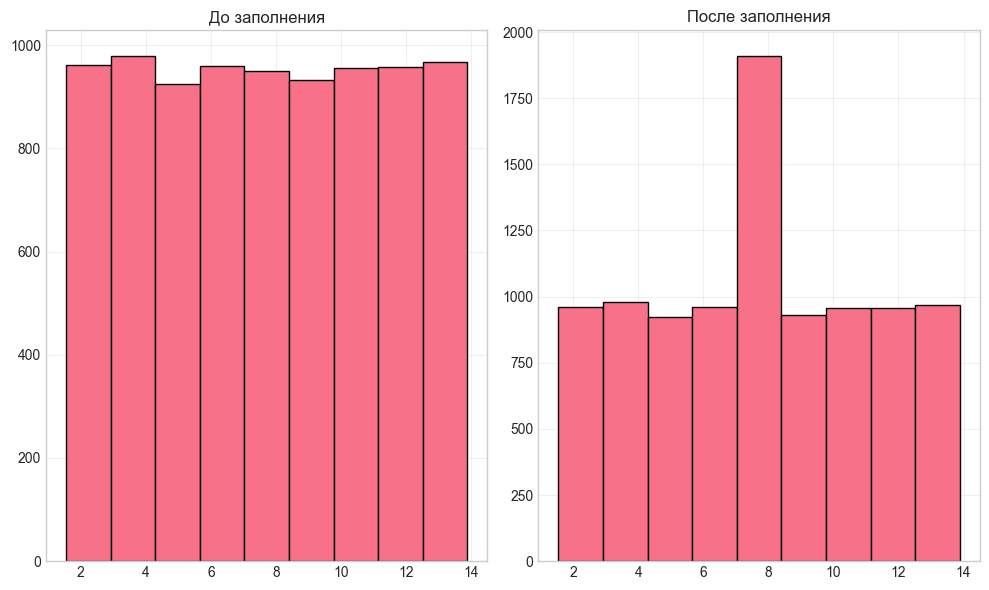

  Заполнение значением 7.7152: KL = 0.1061


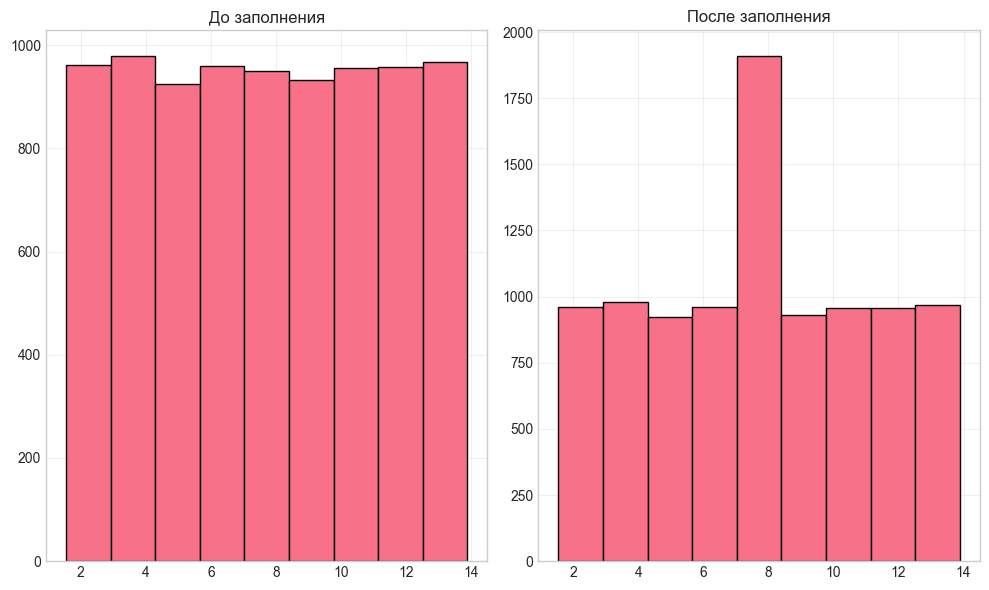

  Заполнение значением 7.7166: KL = 0.0288


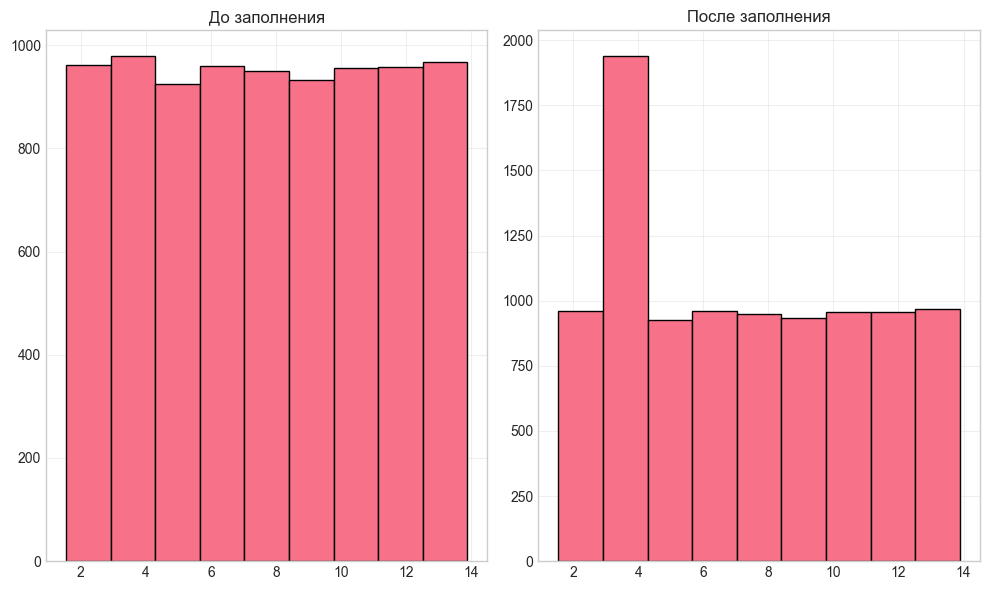

  Заполнение значением 3.0866: KL = 0.0281
  Выбрано значение: 3.0866 (KL = 0.0281)


In [108]:
best_values = {}
for col in missing_cols:
    print(f"\n--- Обработка признака: {col} ---")
    
    candidate_values = [
        X_train[col].mean(),
        X_train[col].median(),
        X_train[col].mode()[0]
    ]
    
    best_kl = float('inf')
    best_val = None
    
    for val in candidate_values:
        kl, _, _ = evaluate_imputation(X_train[col], val)
        print(f"  Заполнение значением {val:.4f}: KL = {kl:.4f}")
        if kl < best_kl:
            best_kl = kl
            best_val = val
    
    best_values[col] = best_val
    print(f"  Выбрано значение: {best_val:.4f} (KL = {best_kl:.4f})")

### 2.2.3. <a id='toc2_2_3_'></a>[Заполнение пропусков статистическими значениями в обучающей выборке](#toc0_)

In [109]:
X_train_stat = X_train.copy()
for col, val in best_values.items():
    X_train_stat[col] = X_train_stat[col].fillna(val)

print("Пропуски в обучающей выборке после статистического заполнения:")
print(X_train_stat.isna().sum())

Пропуски в обучающей выборке после статистического заполнения:
Вектор Мощи                       0
Скорость перехода через портал    0
Приток Силы Потока                0
Ритм магического ядра             0
Поток Энергий                     0
Сила Левого Потока                0
Пламя Стихий                      0
Приток давления Выдоха Истока     0
Давление выдоха Истока            0
Печать Чародея                    0
Эмульсия Истока                   0
Дыхание Истока                    0
Тип Вектора Мощи                  0
dtype: int64


### 2.2.4. <a id='toc2_2_4_'></a>[Машинный подход (KNNImputer)](#toc0_)


--- Обработка признака: Скорость перехода через портал ---


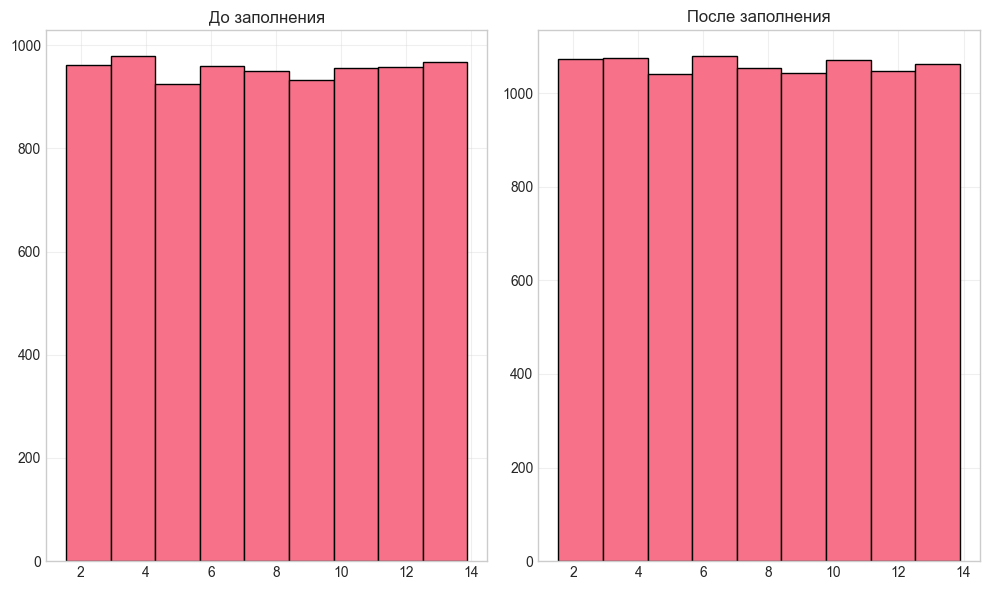

Пропуски в обучающей выборке после KNNImputer:
Вектор Мощи                       0
Скорость перехода через портал    0
Приток Силы Потока                0
Ритм магического ядра             0
Поток Энергий                     0
Сила Левого Потока                0
Пламя Стихий                      0
Приток давления Выдоха Истока     0
Давление выдоха Истока            0
Печать Чародея                    0
Эмульсия Истока                   0
Дыхание Истока                    0
Тип Вектора Мощи                  0
dtype: int64


In [110]:
imputer = KNNImputer(n_neighbors=5)
X_train_knn = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

for col in missing_cols:
    
    print(f"\n--- Обработка признака: {col} ---")

    plt.figure(figsize=(10, 6))

    plt.subplot(1, 2, 1)
    plt.hist(X_train[col].dropna(), bins=9, edgecolor='black', alpha=1)
    plt.title('До заполнения')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.hist(X_train_knn[col], bins=9, edgecolor='black', alpha=1)
    plt.title('После заполнения')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("Пропуски в обучающей выборке после KNNImputer:")
print(X_train_knn.isna().sum())

### 2.2.5. <a id='toc2_2_5_'></a>[Применение результатов к тестовой выборке](#toc0_)

In [111]:
X_test_stat = X_test.copy()
for col, val in best_values.items():
    X_test_stat[col] = X_test_stat[col].fillna(val)

X_test_knn = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Пропуски в тестовой выборке после обработки:")
print("Статистический подход:")
print(X_test_stat.isna().sum())
print("\nМашинный подход (KNNImputer):")
print(X_test_knn.isna().sum())

Пропуски в тестовой выборке после обработки:
Статистический подход:
Вектор Мощи                       0
Скорость перехода через портал    0
Приток Силы Потока                0
Ритм магического ядра             0
Поток Энергий                     0
Сила Левого Потока                0
Пламя Стихий                      0
Приток давления Выдоха Истока     0
Давление выдоха Истока            0
Печать Чародея                    0
Эмульсия Истока                   0
Дыхание Истока                    0
Тип Вектора Мощи                  0
dtype: int64

Машинный подход (KNNImputer):
Вектор Мощи                       0
Скорость перехода через портал    0
Приток Силы Потока                0
Ритм магического ядра             0
Поток Энергий                     0
Сила Левого Потока                0
Пламя Стихий                      0
Приток давления Выдоха Истока     0
Давление выдоха Истока            0
Печать Чародея                    0
Эмульсия Истока                   0
Дыхание Истока          

## 2.3. <a id='toc2_3_'></a>[Дополнительное задание: оценка качества заполнения пропусков (NRMSE)](#toc0_)

### 2.3.1. <a id='toc2_3_1_'></a>[Создание «чистого» датасета](#toc0_)

In [112]:
X_train_clean = X_train.dropna().copy()
y_train_clean = y_train.loc[X_train_clean.index]

print(f"Исходный размер train: {X_train.shape}")
print(f"Чистый train (без пропусков): {X_train_clean.shape}")

Исходный размер train: (9547, 13)
Чистый train (без пропусков): (8586, 13)


### 2.3.2. <a id='toc2_3_2_'></a>[Генерация маскированных данных](#toc0_)

In [113]:
np.random.seed(42)
mask = np.random.rand(*X_train_clean.shape) < 0.1
X_train_masked = X_train_clean.mask(mask)
print(f"Количество пропусков в маскированных данных: {X_train_masked.isna().sum().sum()}")

Количество пропусков в маскированных данных: 11192


### 2.3.3. <a id='toc2_3_3_'></a>[Обучение KNNImputer на маскированных данных](#toc0_)

In [114]:
imputer_eval = KNNImputer(n_neighbors=5)
X_train_imputed = pd.DataFrame(imputer_eval.fit_transform(X_train_masked), columns=X_train_masked.columns, index=X_train_masked.index)

### 2.3.4. <a id='toc2_3_4_'></a>[Вычисление NRMSE](#toc0_)

In [115]:
def nrmse(original, imputed, mask):
    mse = mean_squared_error(original[mask], imputed[mask])
    rmse = np.sqrt(mse)
    nrmse_val = rmse / (original.max() - original.min())
    return nrmse_val

nrmse_results = {}
for col in X_train_clean.columns:
    original = X_train_clean[col]
    imputed = X_train_imputed[col]
    col_mask = mask[:, list(X_train_clean.columns).index(col)]
    nrmse_results[col] = nrmse(original, imputed, col_mask)

print("NRMSE для каждого признака:")
for col, val in nrmse_results.items():
    print(f"  {col}: {val:.6f}")

NRMSE для каждого признака:
  Вектор Мощи: 0.027625
  Скорость перехода через портал: 0.027705
  Приток Силы Потока: 0.006914
  Ритм магического ядра: 0.007826
  Поток Энергий: 0.008217
  Сила Левого Потока: 0.012949
  Пламя Стихий: 0.033863
  Приток давления Выдоха Истока: 0.005802
  Давление выдоха Истока: 0.014405
  Печать Чародея: 0.035109
  Эмульсия Истока: 0.010694
  Дыхание Истока: 0.165369
  Тип Вектора Мощи: 0.040833


# 3. <a id='toc3_'></a>[Лабораторная работа №4](#toc0_)

## 3.1. <a id='toc3_1_'></a>[Поиск и удаление выбросов](#toc0_)

### 3.1.1. <a id='toc3_1_1_'></a>[Анализ распределений и визуализация "Ящик с усами"](#toc0_)

Визуализация распределений для выявления выбросов


Гистограммы распределений признаков:


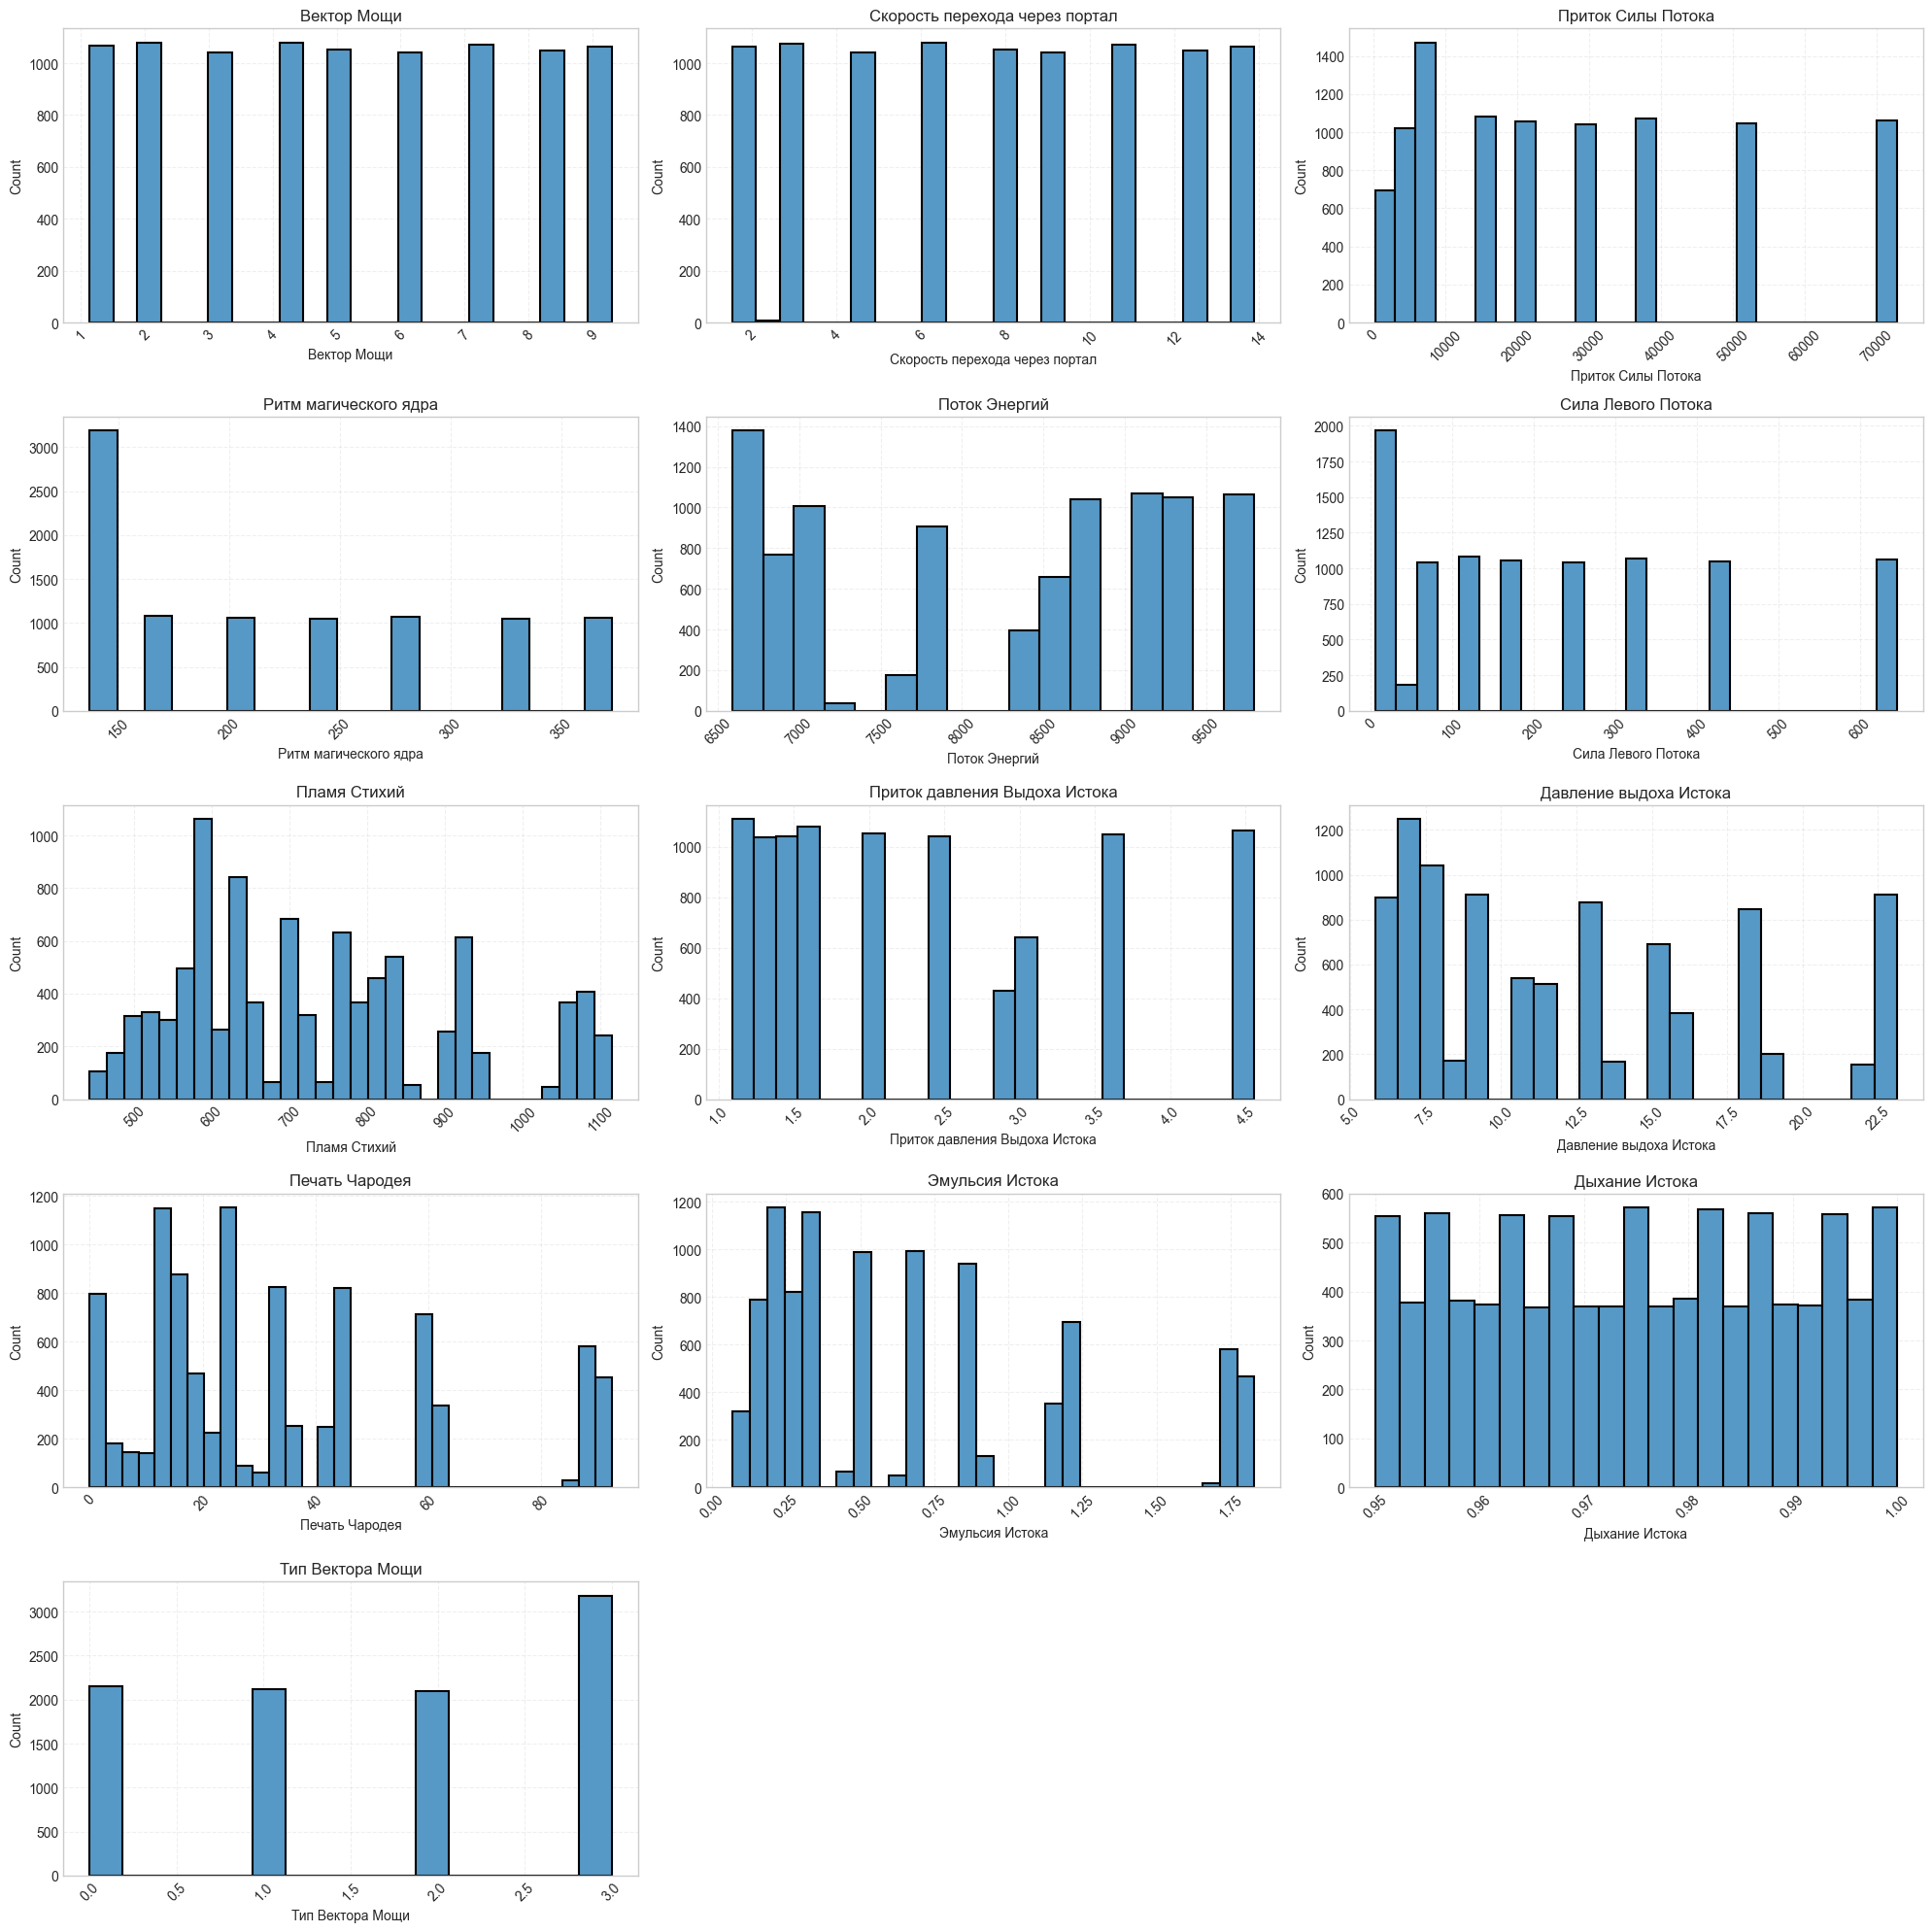


Диаграммы 'Ящик с усами' для выявления выбросов:


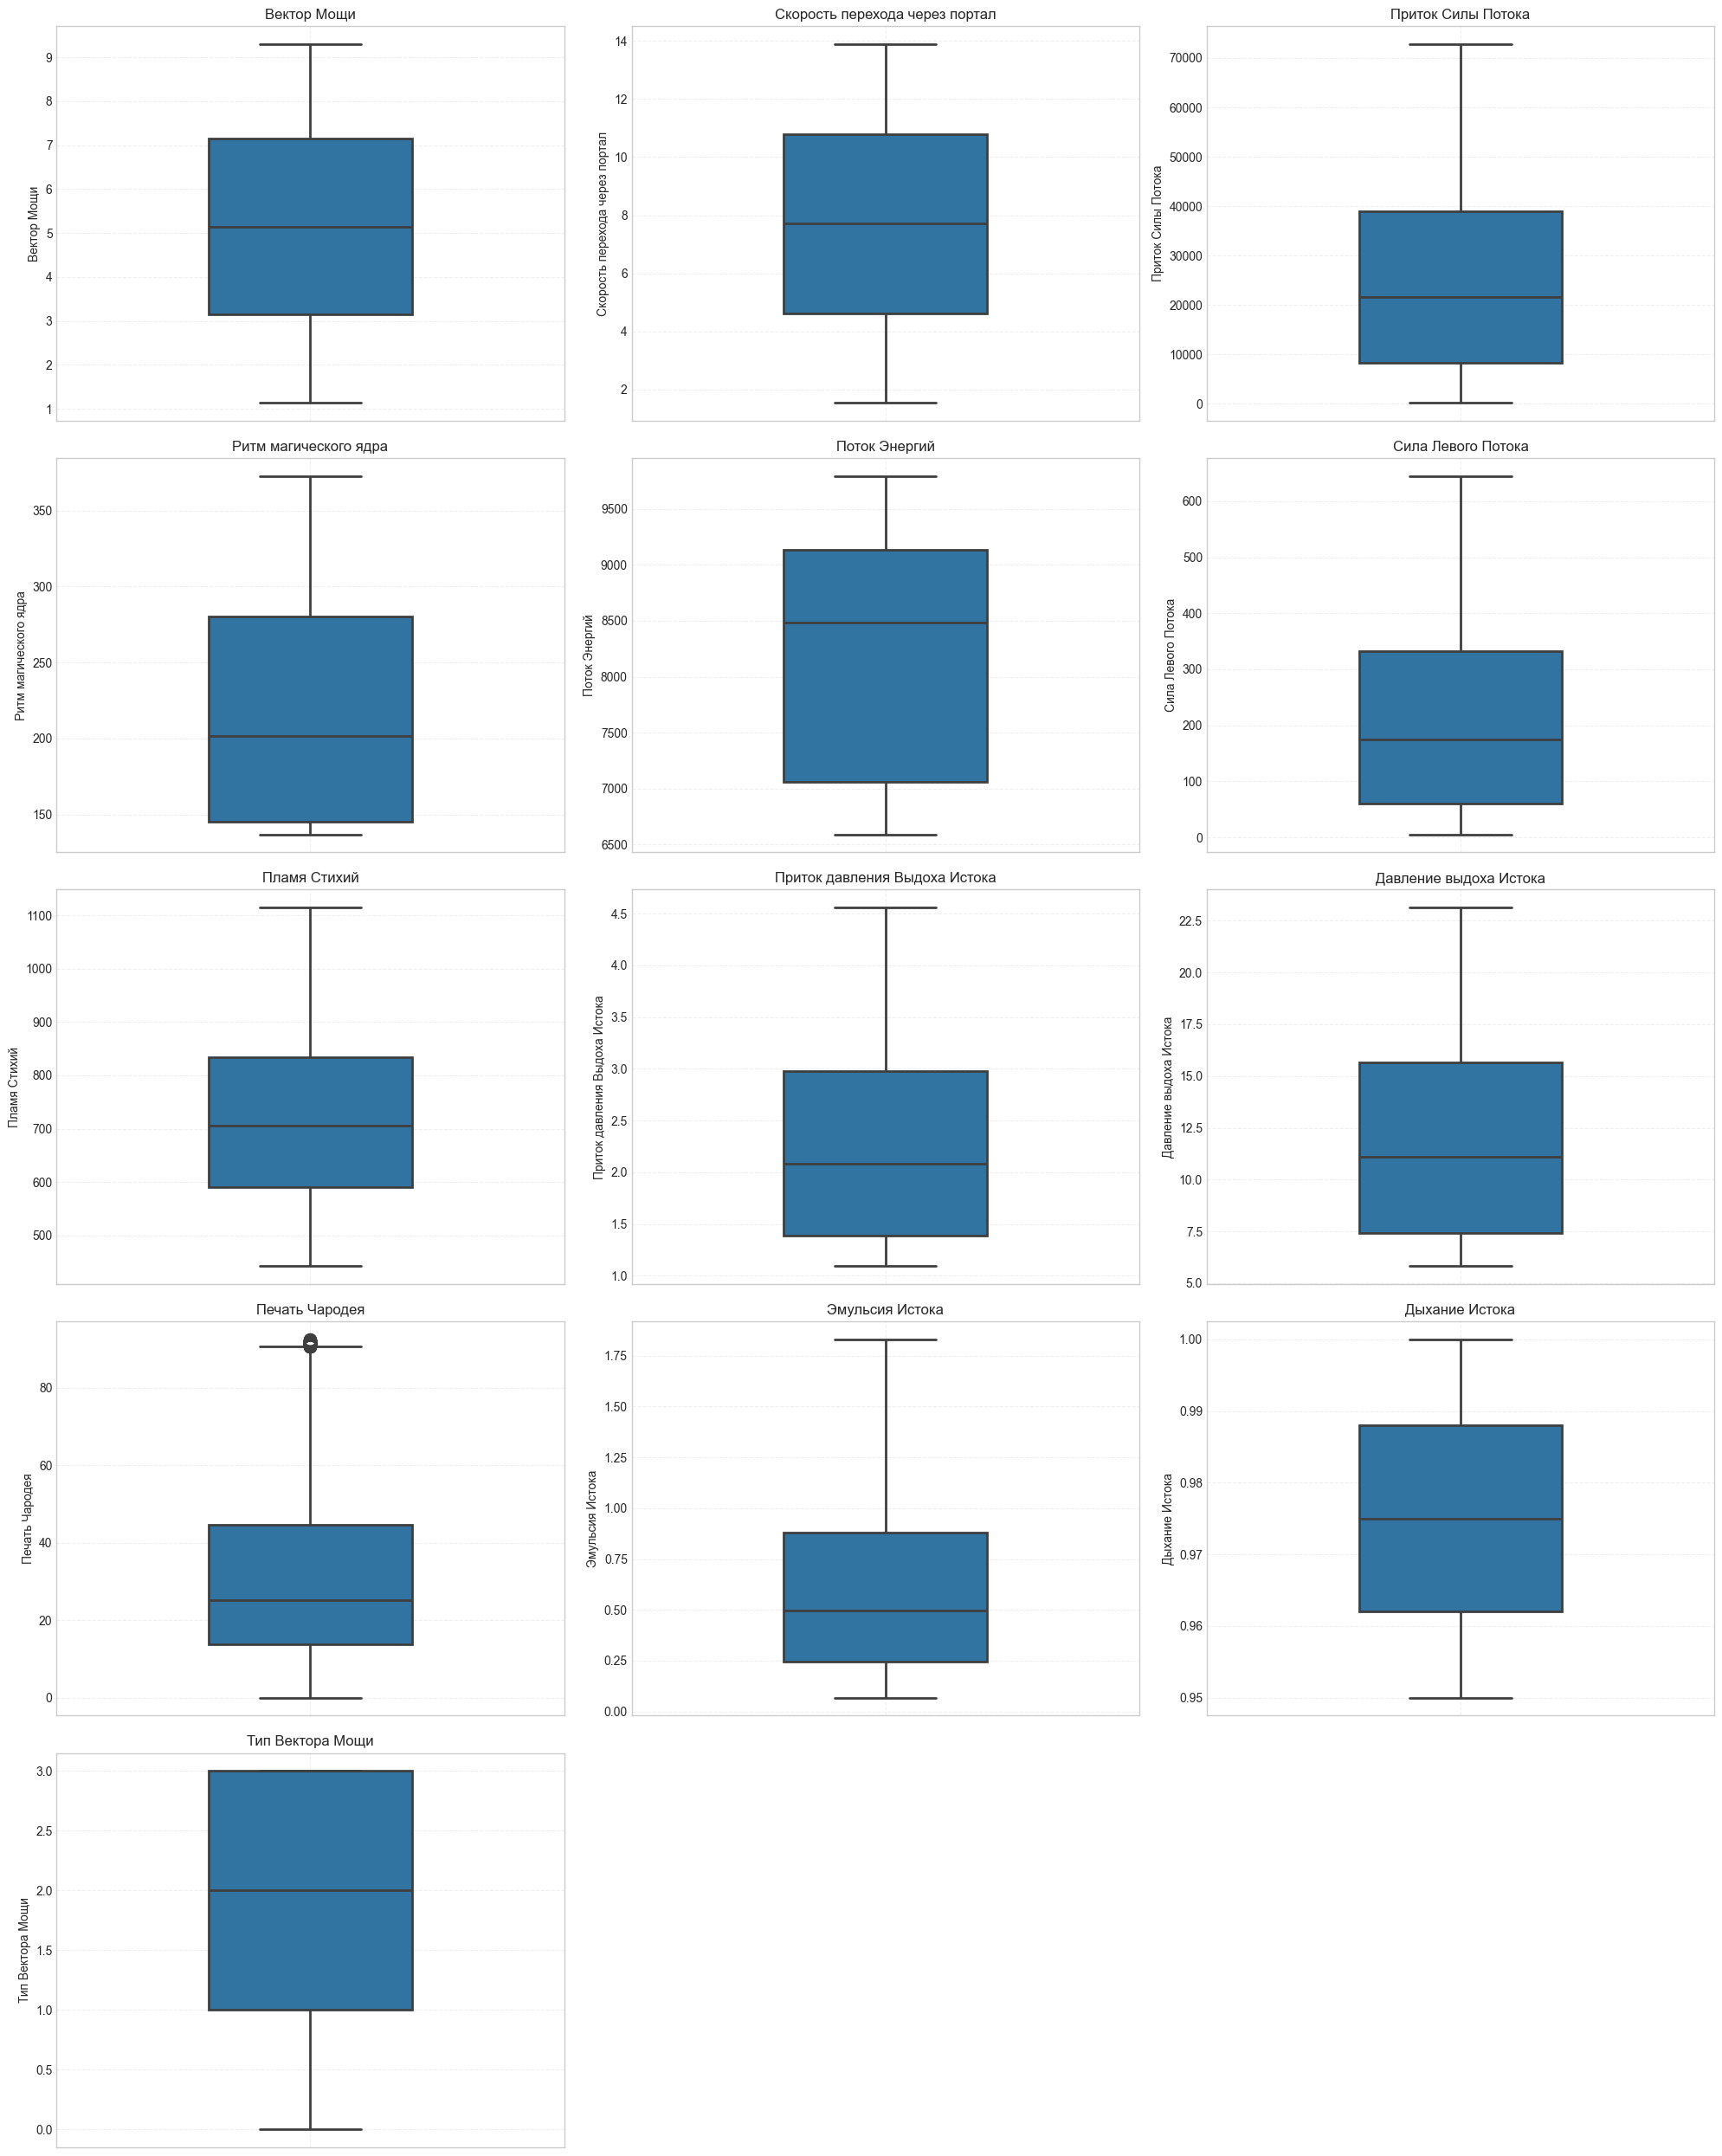

In [116]:
def draw_sns(df, visualization_function, figsize=(20, 20), **kwargs):
    n_col = 3
    n = len(df.columns)
    n_row = int(np.ceil(n / n_col))
    
    fig, axes = plt.subplots(n_row, n_col, figsize=figsize)
    axes = axes.flatten()
    
    for i, col in enumerate(df.columns):
        if visualization_function == sns.boxplot:
            visualization_function(y=df[col], ax=axes[i], **kwargs)
        else:
            visualization_function(x=df[col], ax=axes[i], **kwargs)
        
        axes[i].set_title(col, fontsize=12)
        axes[i].tick_params(axis='x', rotation=45, labelsize=10)
        axes[i].tick_params(axis='y', labelsize=10)
        axes[i].grid(True, alpha=0.3, linestyle='--')
    
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

print("\nГистограммы распределений признаков:")
draw_sns(
    X_train_knn.select_dtypes(include=[np.number]), 
    sns.histplot, 
    figsize=(20, 20),
    alpha=1,
    edgecolor='black',
    linewidth=1.5,
    color='#5799c6'
)

print("\nДиаграммы 'Ящик с усами' для выявления выбросов:")
draw_sns(
    X_train_knn.select_dtypes(include=[np.number]), 
    sns.boxplot, 
    figsize=(20, 25),
    color='#3274a1',
    saturation=1,
    width=0.4,
    fliersize=10,
    linewidth=2
)

### 3.1.2. <a id='toc3_1_2_'></a>[Реализация методов IQR и Robust Z-score](#toc0_)

Функция для вычисления границ IQR

In [117]:
def calc_bounds_iqr(x):
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return lower_bound, upper_bound

Функция для проверки выбросов методом IQR

In [118]:
def check_feature_outliers_iqr(x):
    lower_bound, upper_bound = calc_bounds_iqr(x)
    return ((x < lower_bound) | (x > upper_bound)).values

Функция для проверки выбросов методом Robust Z-score

In [119]:
def check_feature_outliers_robust_zscore(x, threshold=3):
    median = np.median(x)
    mad = np.median(np.abs(x - median))
    
    if mad == 0:
        mad = np.std(x)
        if mad == 0:
            return np.zeros(len(x), dtype=bool)
    
    robust_z_scores = 0.6745 * (x - median) / mad
    return (np.abs(robust_z_scores) > threshold).values

Функция для поиска объектов с выбросами в датасете

In [120]:
def check_dataset_outliers(df, outliers_method, **kwargs):
    outliers_flags = []
    for column in df.select_dtypes(include=[np.number]).columns:
        outliers_flags.append(outliers_method(df[column], **kwargs))
    
    return np.any(np.array(outliers_flags), axis=0)

### 3.1.3. <a id='toc3_1_3_'></a>[Поиск выбросов с использованием обоих методов](#toc0_)

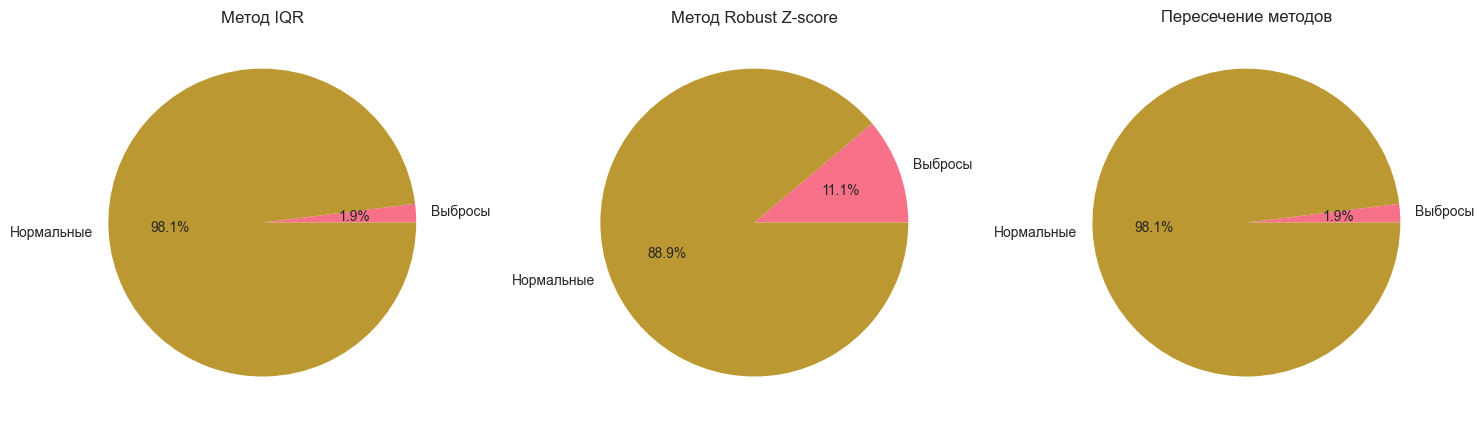

Объектов с выбросами (IQR): 186
Объектов с выбросами (Robust Z-score): 1063
Объектов с выбросами (пересечение): 186


In [121]:
outliers_iqr = check_dataset_outliers(X_train_knn, check_feature_outliers_iqr)
outliers_robust = check_dataset_outliers(X_train_knn, check_feature_outliers_robust_zscore, threshold=3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

iqr_counts = [np.sum(outliers_iqr), len(outliers_iqr) - np.sum(outliers_iqr)]
axes[0].pie(iqr_counts, labels=['Выбросы', 'Нормальные'], autopct='%1.1f%%')
axes[0].set_title('Метод IQR')

robust_counts = [np.sum(outliers_robust), len(outliers_robust) - np.sum(outliers_robust)]
axes[1].pie(robust_counts, labels=['Выбросы', 'Нормальные'], autopct='%1.1f%%')
axes[1].set_title('Метод Robust Z-score')

intersection_outliers = outliers_iqr & outliers_robust
intersection_counts = [np.sum(intersection_outliers), len(intersection_outliers) - np.sum(intersection_outliers)]
axes[2].pie(intersection_counts, labels=['Выбросы', 'Нормальные'], autopct='%1.1f%%')
axes[2].set_title('Пересечение методов')

plt.tight_layout()
plt.show()

print(f"Объектов с выбросами (IQR): {np.sum(outliers_iqr)}")
print(f"Объектов с выбросами (Robust Z-score): {np.sum(outliers_robust)}")
print(f"Объектов с выбросами (пересечение): {np.sum(intersection_outliers)}")

### 3.1.4. <a id='toc3_1_4_'></a>[Удаление объектов с выбросами](#toc0_)

Сохраняем индексы выбросов для последующего удаления и удаляем их

In [122]:
outlier_indices = X_train_knn[intersection_outliers].index
print(f"Индексы объектов с выбросами: {list(outlier_indices)[:20]}...")

X_train_no_outliers = X_train_knn.drop(index=outlier_indices).copy()
y_train_no_outliers = y_train.drop(index=outlier_indices).copy()

print(f"\nРазмеры данных после удаления выбросов:")
print(f"Обучающая выборка: {X_train_no_outliers.shape}")
print(f"Целевая переменная: {y_train_no_outliers.shape}")

Индексы объектов с выбросами: [620, 3068, 1745, 1889, 530, 782, 476, 2870, 809, 1880, 2177, 1034, 1259, 3077, 3329, 323, 2375, 3527, 611, 2114]...

Размеры данных после удаления выбросов:
Обучающая выборка: (9361, 13)
Целевая переменная: (9361,)


## 3.2. <a id='toc3_2_'></a>[Поиск и удаление аномалий](#toc0_)

### 3.2.1. <a id='toc3_2_1_'></a>[Подготовка данных и снижение размерности](#toc0_)

Масштабируем данные для алгоритмов поиска аномалий, также снижаем размерность для визуализации

In [123]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_no_outliers.select_dtypes(include=[np.number]))

print("Снижение размерности для визуализации...")
umap_reducer = UMAP(n_components=2, random_state=42)
X_2d = umap_reducer.fit_transform(X_scaled)

def draw_anomaly(X_2d, anomaly_mask):
    plt.figure(figsize=(8, 6))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5, s=20, c='blue', label='Нормальные')
    plt.scatter(X_2d[anomaly_mask, 0], X_2d[anomaly_mask, 1], c='red', marker='x', s=100, linewidth=2, label='Аномалии')
    plt.xlabel('UMAP Component 1')
    plt.ylabel('UMAP Component 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def draw_anomaly_pie(anomaly_mask, title=""):
    normal_count = np.sum(~anomaly_mask)
    anomaly_count = np.sum(anomaly_mask)
    
    labels = ['Нормальные объекты', 'Аномалии']
    sizes = [normal_count, anomaly_count]
    
    plt.figure(figsize=(8, 6))
    plt.pie(sizes, labels=[f'{normal_count}\n({normal_count/len(anomaly_mask)*100:.0f}%)', f'{anomaly_count}\n({anomaly_count/len(anomaly_mask)*100:.0f}%)'], autopct='', colors=['lightblue', 'lightcoral'])
    plt.title(f'{title}\nВсего объектов: {len(anomaly_mask)}', fontsize=14, pad=20)
    plt.legend(labels, loc='lower right')
    plt.tight_layout()
    plt.show()

Снижение размерности для визуализации...


### 3.2.2. <a id='toc3_2_2_'></a>[Применение Isolation Forest](#toc0_)

Применение Isolation Forest для поиска аномалий...
Isolation Forest обнаружено аномалий: 936


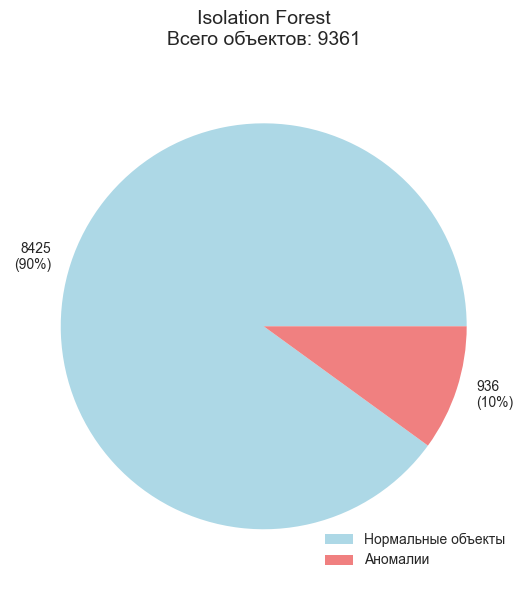

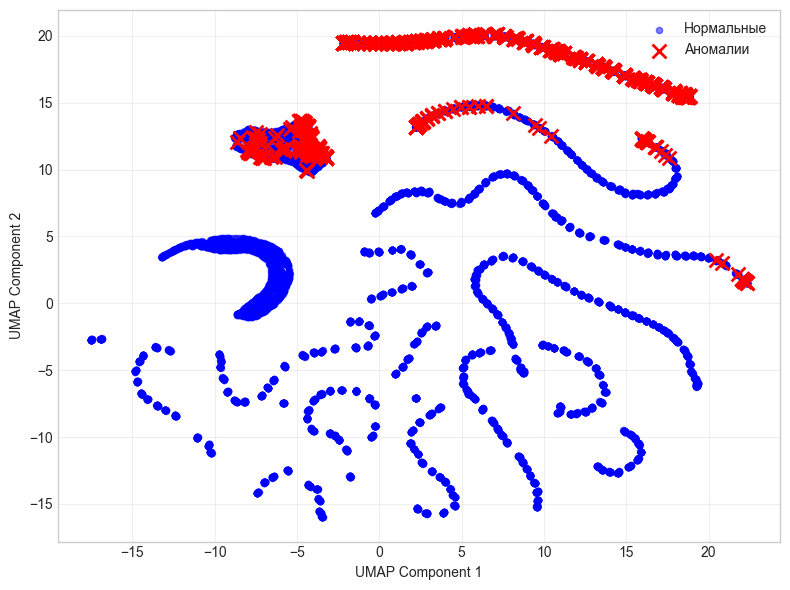

In [124]:
print("Применение Isolation Forest для поиска аномалий...")
iso_forest = IsolationForest(contamination=0.1, random_state=42)
iso_predictions = iso_forest.fit_predict(X_scaled)
iso_anomaly_mask = iso_predictions == -1

print(f"Isolation Forest обнаружено аномалий: {np.sum(iso_anomaly_mask)}")
draw_anomaly_pie(iso_anomaly_mask, "Isolation Forest")
draw_anomaly(X_2d, iso_anomaly_mask)

### 3.2.3. <a id='toc3_2_3_'></a>[Применение One-Class SVM](#toc0_)

Применение One-Class SVM для поиска аномалий...
One-Class SVM обнаружено аномалий: 937


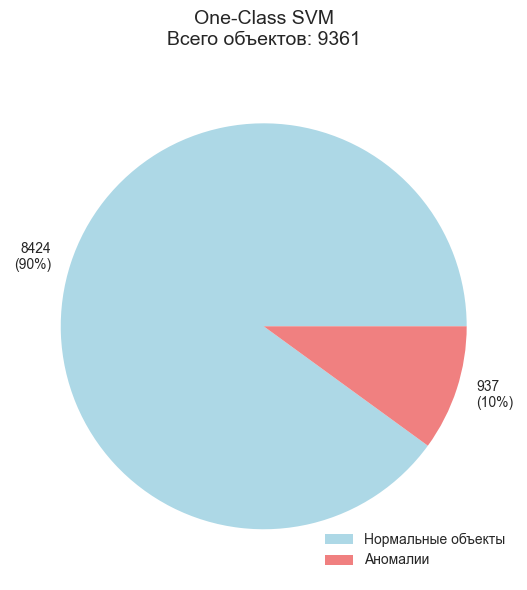

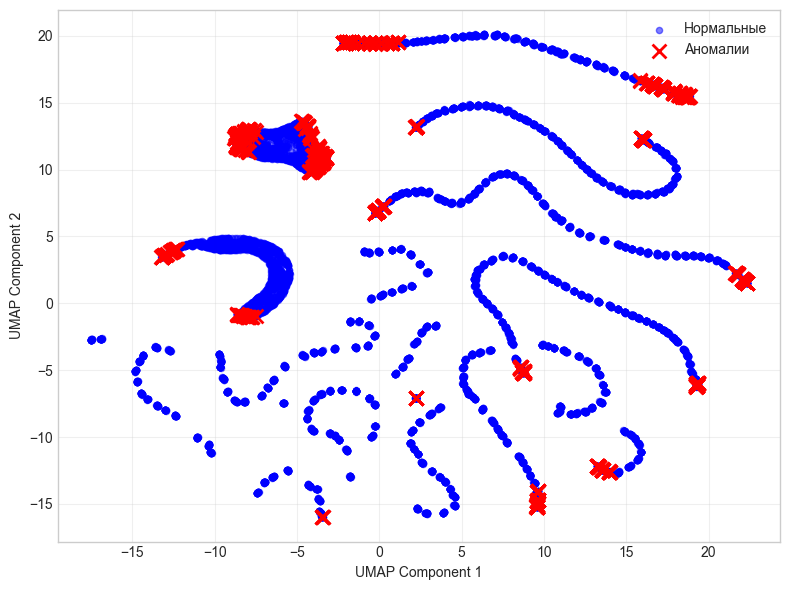

In [125]:
print("Применение One-Class SVM для поиска аномалий...")
oc_svm = OneClassSVM(nu=0.1, kernel='rbf', gamma='scale')
oc_svm_predictions = oc_svm.fit_predict(X_scaled)
oc_svm_anomaly_mask = oc_svm_predictions == -1

print(f"One-Class SVM обнаружено аномалий: {np.sum(oc_svm_anomaly_mask)}")
draw_anomaly_pie(oc_svm_anomaly_mask, "One-Class SVM")
draw_anomaly(X_2d, oc_svm_anomaly_mask)

### 3.2.4. <a id='toc3_2_4_'></a>[Применение DBSCAN](#toc0_)

Применение DBSCAN для поиска аномалий...
DBSCAN обнаружено аномалий: 5


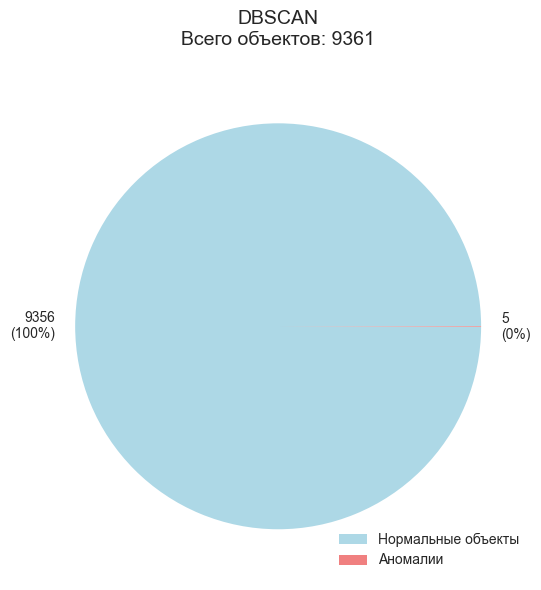

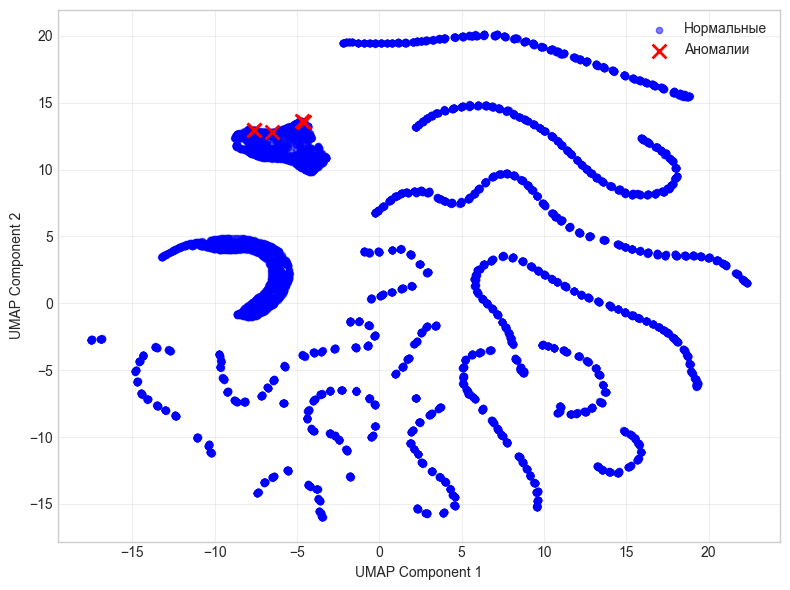

In [126]:
print("Применение DBSCAN для поиска аномалий...")
dbscan = DBSCAN(eps=0.3, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)
dbscan_anomaly_mask = dbscan_labels == -1

print(f"DBSCAN обнаружено аномалий: {np.sum(dbscan_anomaly_mask)}")
draw_anomaly_pie(dbscan_anomaly_mask, "DBSCAN")
draw_anomaly(X_2d, dbscan_anomaly_mask)


### 3.2.5. <a id='toc3_2_5_'></a>[Определение общих аномалий](#toc0_)

Объединяем результаты всех трех методов

Общие аномалии (все 3 метода): 2


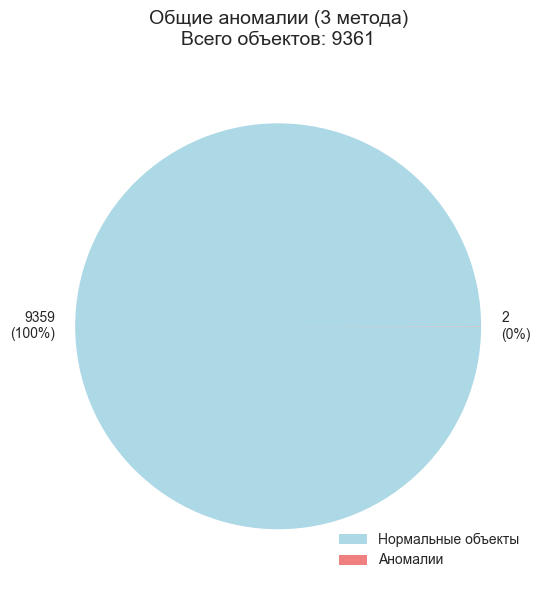

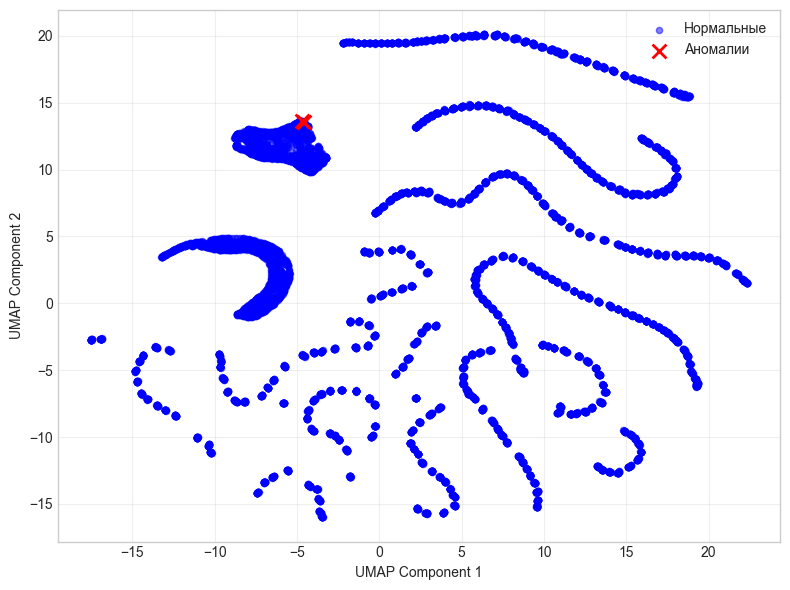

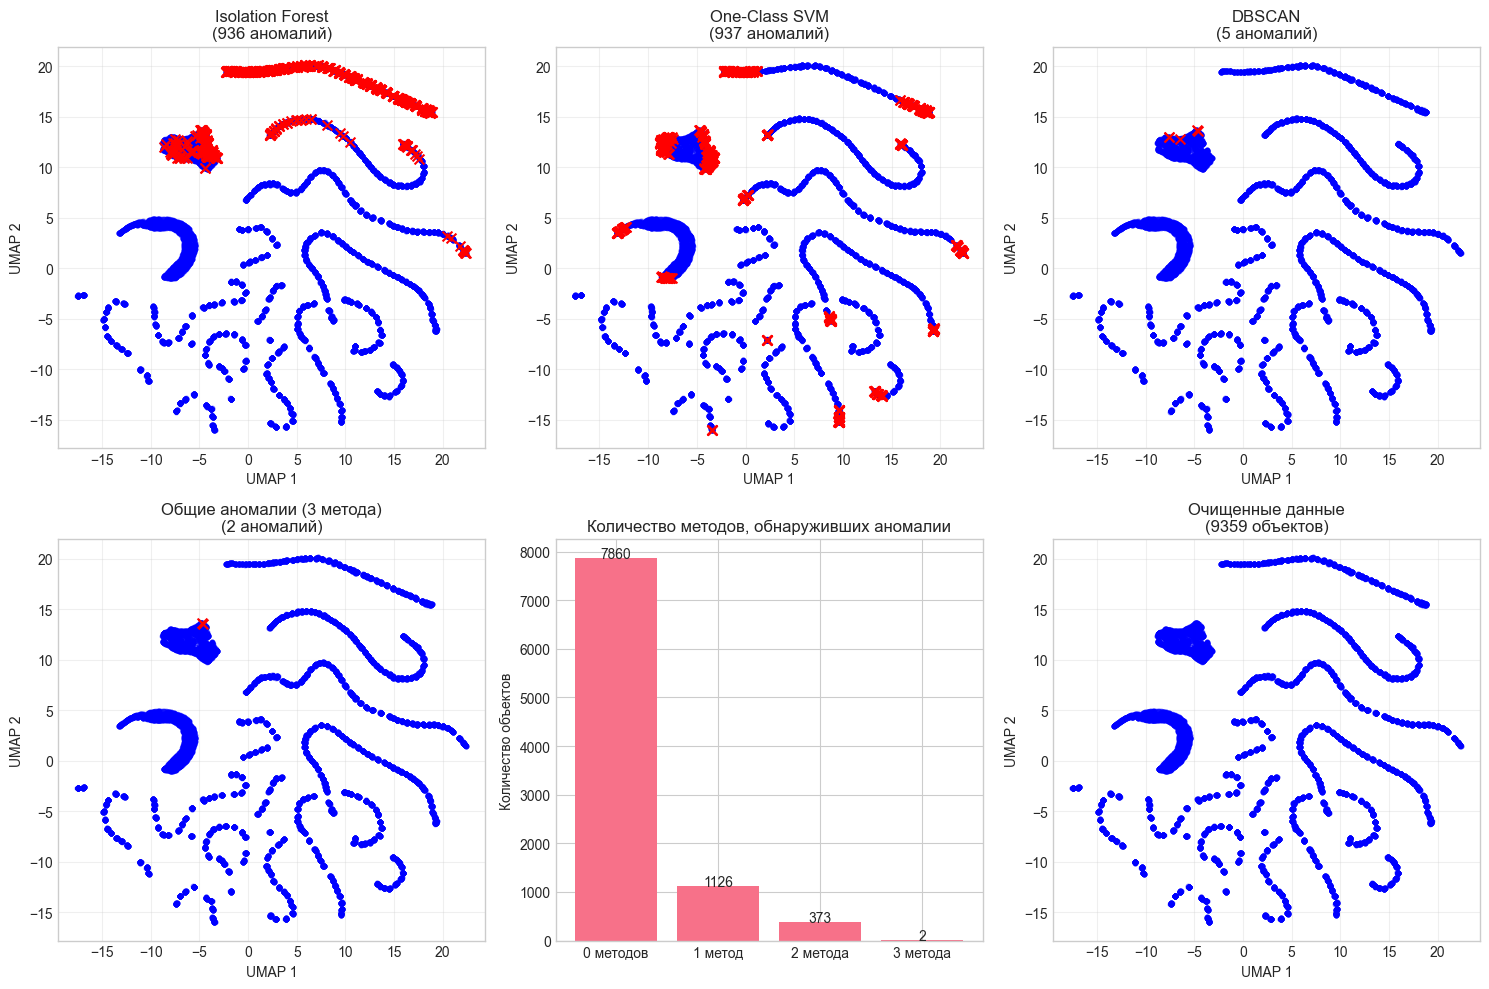

In [127]:
anomaly_masks = np.array([iso_anomaly_mask, oc_svm_anomaly_mask, dbscan_anomaly_mask])
common_anomaly_mask = np.all(anomaly_masks, axis=0)

print(f"Общие аномалии (все 3 метода): {np.sum(common_anomaly_mask)}")
draw_anomaly_pie(common_anomaly_mask, "Общие аномалии (3 метода)")
draw_anomaly(X_2d, common_anomaly_mask)

plt.figure(figsize=(15, 10))

# График 1: Isolation Forest
plt.subplot(2, 3, 1)
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5, s=10, c='blue')
plt.scatter(X_2d[iso_anomaly_mask, 0], X_2d[iso_anomaly_mask, 1], c='red', marker='x', s=50)
plt.title(f'Isolation Forest\n({np.sum(iso_anomaly_mask)} аномалий)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True, alpha=0.3)

# График 2: One-Class SVM
plt.subplot(2, 3, 2)
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5, s=10, c='blue')
plt.scatter(X_2d[oc_svm_anomaly_mask, 0], X_2d[oc_svm_anomaly_mask, 1], c='red', marker='x', s=50)
plt.title(f'One-Class SVM\n({np.sum(oc_svm_anomaly_mask)} аномалий)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True, alpha=0.3)

# График 3: DBSCAN
plt.subplot(2, 3, 3)
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5, s=10, c='blue')
plt.scatter(X_2d[dbscan_anomaly_mask, 0], X_2d[dbscan_anomaly_mask, 1], c='red', marker='x', s=50)
plt.title(f'DBSCAN\n({np.sum(dbscan_anomaly_mask)} аномалий)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True, alpha=0.3)

# График 4: Общие аномалии
plt.subplot(2, 3, 4)
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5, s=10, c='blue')
plt.scatter(X_2d[common_anomaly_mask, 0], X_2d[common_anomaly_mask, 1], c='red', marker='x', s=50)
plt.title(f'Общие аномалии (3 метода)\n({np.sum(common_anomaly_mask)} аномалий)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True, alpha=0.3)

# График 5: Сравнение обнаруженных аномалий
plt.subplot(2, 3, 5)
all_methods = iso_anomaly_mask.astype(int) + oc_svm_anomaly_mask.astype(int) + dbscan_anomaly_mask.astype(int)
unique, counts = np.unique(all_methods, return_counts=True)

plt.bar(['0 методов', '1 метод', '2 метода', '3 метода'], counts)
plt.title('Количество методов, обнаруживших аномалии')
plt.ylabel('Количество объектов')
for i, v in enumerate(counts):
    plt.text(i, v + 0.1, str(v), ha='center')

# График 6: Финал - очищенные данные
plt.subplot(2, 3, 6)
X_clean_2d = X_2d[~common_anomaly_mask]
plt.scatter(X_clean_2d[:, 0], X_clean_2d[:, 1], alpha=0.5, s=10, c='blue')
plt.title(f'Очищенные данные\n({len(X_clean_2d)} объектов)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2.6. <a id='toc3_2_6_'></a>[Удаление аномалий и итоговая статистика](#toc0_)

ИТОГОВАЯ СТАТИСТИКА
Начальный размер обучающей выборки:            9547
Удалено объектов с выбросами (IQR & Robust Z):        186
Удалено аномальных объектов (3 метода):           2
Итоговый размер обучающей выборки:             9359
Всего удалено объектов:                         188
Процент удаленных данных:                     1.97%


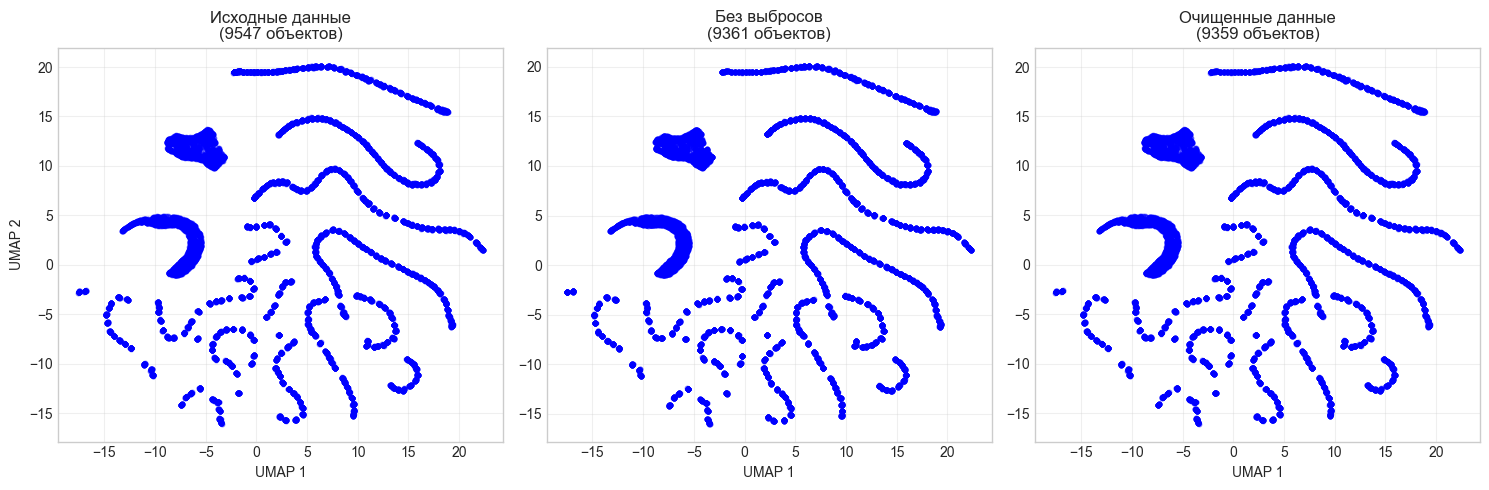

In [128]:
anomaly_indices = X_train_no_outliers.index[common_anomaly_mask]
X_train_clean = X_train_no_outliers.drop(index=anomaly_indices).copy()
y_train_clean = y_train_no_outliers.drop(index=anomaly_indices).copy()

initial_size = len(X_train_knn)
outliers_removed = len(outlier_indices)
anomalies_removed = len(anomaly_indices)
final_size = len(X_train_clean)

print("="*60)
print("ИТОГОВАЯ СТАТИСТИКА")
print("="*60)
print(f"{'Начальный размер обучающей выборки:':<40} {initial_size:>10}")
print(f"{'Удалено объектов с выбросами (IQR & Robust Z):':<40} {outliers_removed:>10}")
print(f"{'Удалено аномальных объектов (3 метода):':<40} {anomalies_removed:>10}")
print(f"{'Итоговый размер обучающей выборки:':<40} {final_size:>10}")
print(f"{'Всего удалено объектов:':<40} {initial_size - final_size:>10}")
print(f"{'Процент удаленных данных:':<40} {(initial_size - final_size)/initial_size*100:>9.2f}%")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

X_initial_2d = umap_reducer.transform(scaler.transform(X_train_knn.select_dtypes(include=[np.number])))
axes[0].scatter(X_initial_2d[:, 0], X_initial_2d[:, 1], alpha=0.5, s=10, c='blue')
axes[0].set_title(f'Исходные данные\n({initial_size} объектов)')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].grid(True, alpha=0.3)

X_no_outliers_2d = umap_reducer.transform(scaler.transform(X_train_no_outliers.select_dtypes(include=[np.number])))
axes[1].scatter(X_no_outliers_2d[:, 0], X_no_outliers_2d[:, 1], alpha=0.5, s=10, c='blue')
axes[1].set_title(f'Без выбросов\n({len(X_train_no_outliers)} объектов)')
axes[1].set_xlabel('UMAP 1')
axes[1].grid(True, alpha=0.3)

X_clean_2d = umap_reducer.transform(scaler.transform(X_train_clean.select_dtypes(include=[np.number])))
axes[2].scatter(X_clean_2d[:, 0], X_clean_2d[:, 1], alpha=0.5, s=10, c='blue')
axes[2].set_title(f'Очищенные данные\n({final_size} объектов)')
axes[2].set_xlabel('UMAP 1')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. <a id='toc4_'></a>[Лабораторная работа №5](#toc0_)

## 4.1. <a id='toc4_1_'></a>[Тепловая карта корреляции признаков](#toc0_)

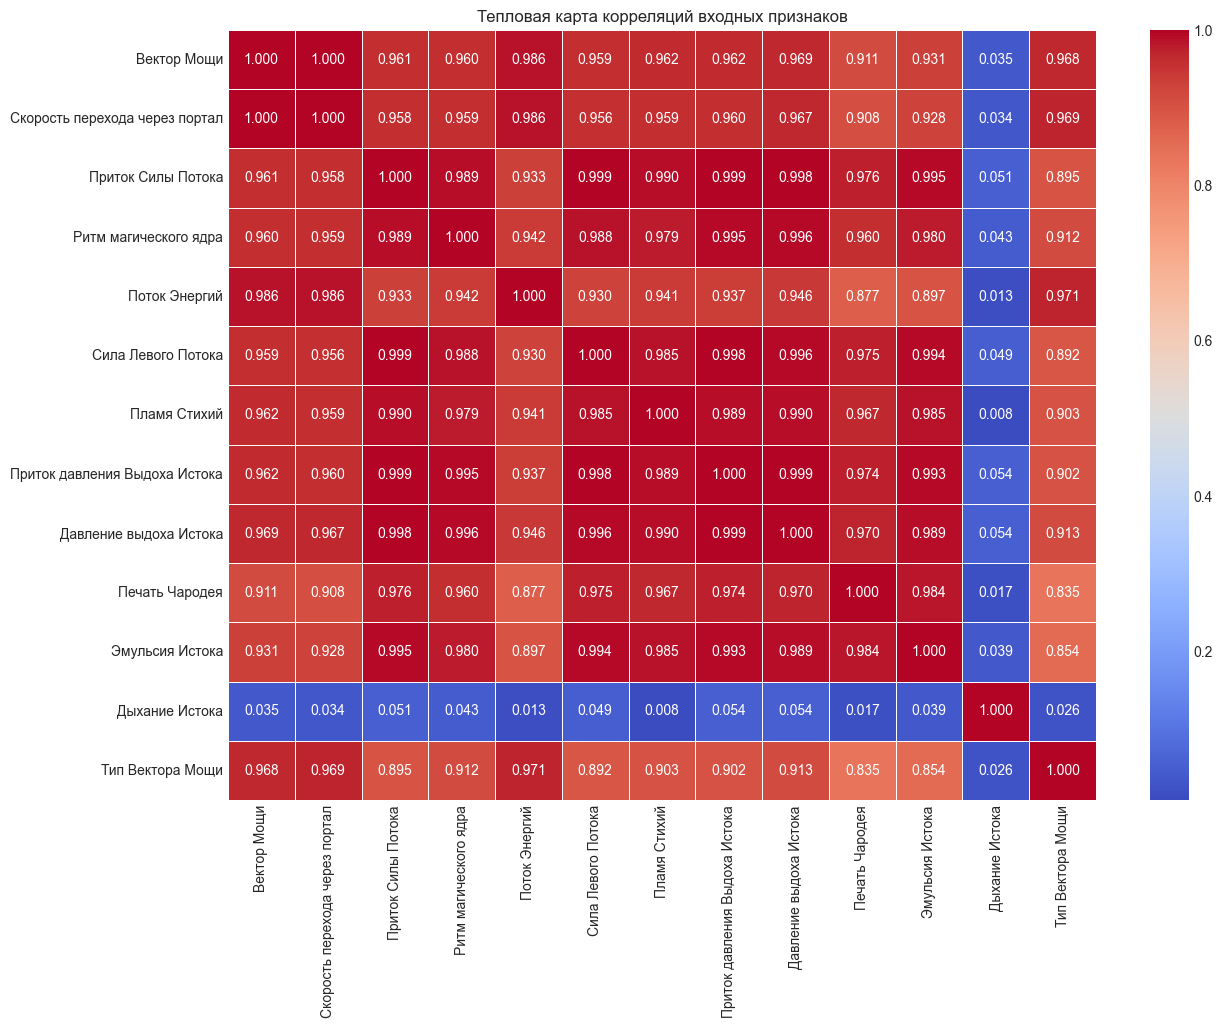

Анализ сильных корреляций (>0.99):
  Найдено 13 сильных корреляций:
    Вектор Мощи <-> Скорость перехода через портал: 0.9999
    Приток Силы Потока <-> Сила Левого Потока: 0.9991
    Приток Силы Потока <-> Пламя Стихий: 0.9904
    Приток Силы Потока <-> Приток давления Выдоха Истока: 0.9989
    Приток Силы Потока <-> Давление выдоха Истока: 0.9975
    Приток Силы Потока <-> Эмульсия Истока: 0.9951
    Ритм магического ядра <-> Приток давления Выдоха Истока: 0.9949
    Ритм магического ядра <-> Давление выдоха Истока: 0.9959
    Сила Левого Потока <-> Приток давления Выдоха Истока: 0.9980
    Сила Левого Потока <-> Давление выдоха Истока: 0.9961
    Сила Левого Потока <-> Эмульсия Истока: 0.9941
    Приток давления Выдоха Истока <-> Давление выдоха Истока: 0.9994
    Приток давления Выдоха Истока <-> Эмульсия Истока: 0.9929


In [310]:
plt.figure(figsize=(14, 10))
corr_matrix = X_train_clean.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', linewidths=0.5)
plt.title('Тепловая карта корреляций входных признаков')
plt.show()

print("Анализ сильных корреляций (>0.99):")
strong_correlations = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.99:
            strong_correlations.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_val
            ))

if strong_correlations:
    print(f"  Найдено {len(strong_correlations)} сильных корреляций:")
    for col1, col2, corr_val in strong_correlations:
        print(f"    {col1} <-> {col2}: {corr_val:.4f}")
else:
    print("  Сильных корреляций (>0.99) не обнаружено")

## 4.2. <a id='toc4_2_'></a>[Использование формул прикладной области для устранения мультиколлинеарности](#toc0_)

### 4.2.1. <a id='toc4_2_1_'></a>[Генерация новых признаков](#toc0_)

In [311]:
X_train_transformed = X_train_clean.copy()
X_test_transformed = X_test.copy()

X_train_transformed = X_train_transformed.drop(columns=['Вектор Мощи'])
X_test_transformed = X_test_transformed.drop(columns=['Вектор Мощи'])

X_train_transformed['Суммарная_мощность_потоков'] = X_train_transformed['Сила Левого Потока'] * 2 + X_train_transformed['Приток Силы Потока']
X_test_transformed['Суммарная_мощность_потоков'] = X_test_transformed['Сила Левого Потока'] * 2 + X_test_transformed['Приток Силы Потока']

X_train_transformed['Общая_сила_ядра'] = X_train_transformed['Ритм магического ядра'] * X_train_transformed['Приток Силы Потока']
X_test_transformed['Общая_сила_ядра'] = X_test_transformed['Ритм магического ядра'] * X_test_transformed['Приток Силы Потока']

X_train_transformed['Общее_давление_выхода'] = X_train_transformed['Приток давления Выдоха Истока'] + X_train_transformed['Давление выдоха Истока']
X_test_transformed['Общее_давление_выхода'] = X_test_transformed['Приток давления Выдоха Истока'] + X_test_transformed['Давление выдоха Истока']

X_train_transformed['Магическая_производительность'] = X_train_transformed['Скорость перехода через портал'] / X_train_transformed['Эмульсия Истока']
X_test_transformed['Магическая_производительность'] = X_test_transformed['Скорость перехода через портал'] / X_test_transformed['Эмульсия Истока']

X_train_transformed['Эффективность_ядра'] = X_train_transformed['Общая_сила_ядра'] / X_train_transformed['Эмульсия Истока']
X_test_transformed['Эффективность_ядра'] = X_test_transformed['Общая_сила_ядра'] / X_test_transformed['Эмульсия Истока']

X_train_transformed['Магическая_мощность'] = X_train_transformed['Эмульсия Истока'] * X_train_transformed['Общее_давление_выхода']
X_test_transformed['Магическая_мощность'] = X_test_transformed['Эмульсия Истока'] * X_test_transformed['Общее_давление_выхода']


### 4.2.2. <a id='toc4_2_2_'></a>[Удаление исходных признаков, которые были заменены](#toc0_)

In [312]:
cols_to_drop = [
    'Скорость перехода через портал',
    'Приток Силы Потока',
    'Ритм магического ядра',
    'Приток давления Выдоха Истока',
    'Давление выдоха Истока',
    'Эмульсия Истока',
    'Сила Левого Потока',
    'Пламя Стихий'
]
X_train_transformed = X_train_transformed.drop(columns=cols_to_drop)
X_test_transformed = X_test_transformed.drop(columns=cols_to_drop)

print("Размерность после замены признаков:")
print(f"  Train: {X_train_transformed.shape}")
print(f"  Test:  {X_test_transformed.shape}")

Размерность после замены признаков:
  Train: (9359, 10)
  Test:  (2387, 10)


### 4.2.3. <a id='toc4_2_3_'></a>[Проверка мультиколлинеарности после преобразований](#toc0_)

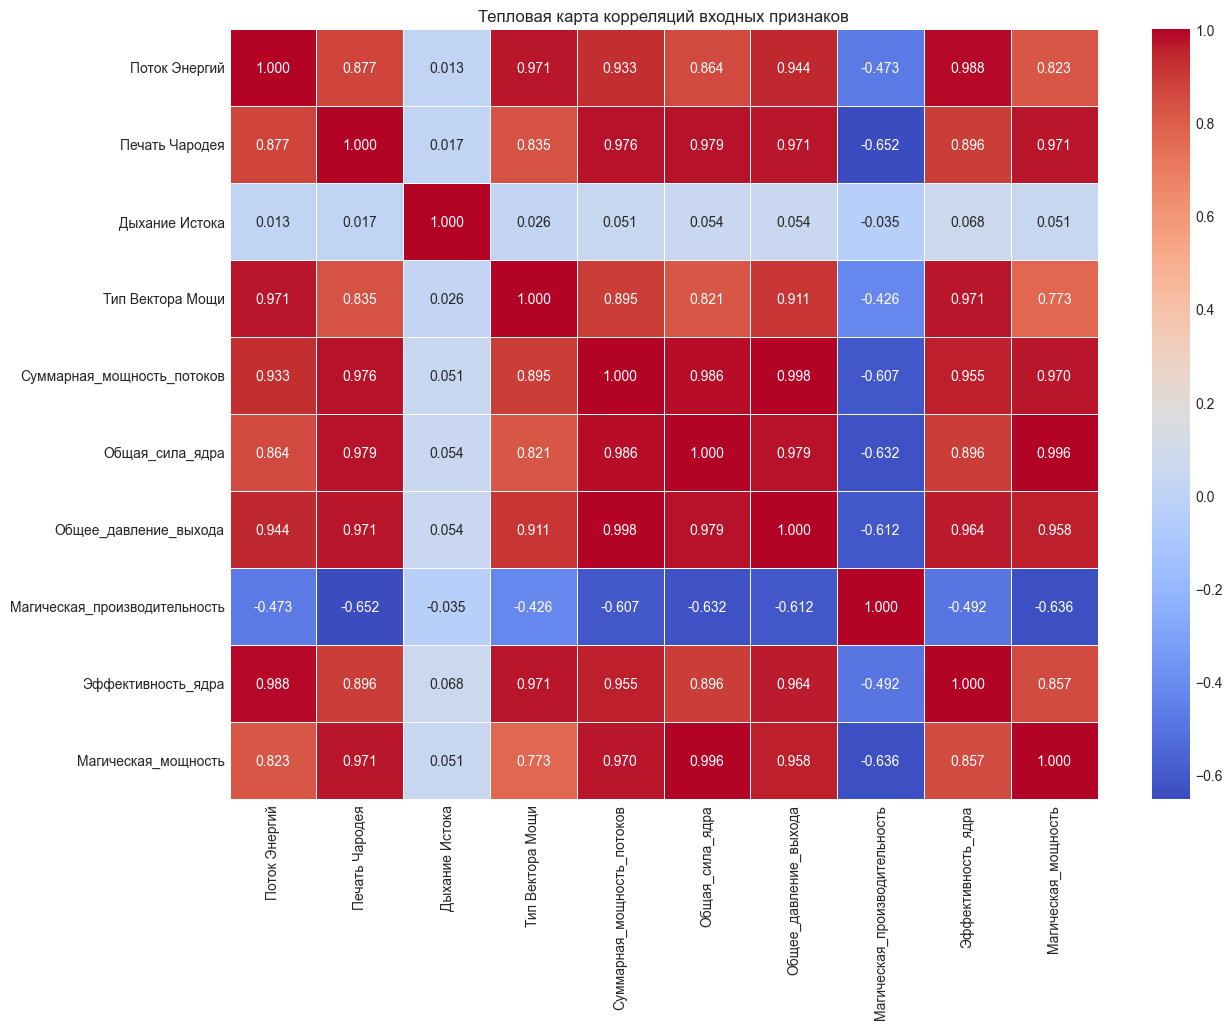

Анализ сильных корреляций (>0.99):
  Найдено 2 сильных корреляций:
    Суммарная_мощность_потоков <-> Общее_давление_выхода: 0.9978
    Общая_сила_ядра <-> Магическая_мощность: 0.9959


In [313]:
plt.figure(figsize=(14, 10))
corr_matrix = X_train_transformed.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', linewidths=0.5)
plt.title('Тепловая карта корреляций входных признаков')
plt.show()

print("Анализ сильных корреляций (>0.99):")
strong_correlations = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.99:
            strong_correlations.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_val
            ))

if strong_correlations:
    print(f"  Найдено {len(strong_correlations)} сильных корреляций:")
    for col1, col2, corr_val in strong_correlations:
        print(f"    {col1} <-> {col2}: {corr_val:.4f}")
else:
    print("  Сильных корреляций (>0.99) не обнаружено")

In [314]:
cols_to_drop_final = ['Общее_давление_выхода', 'Магическая_мощность']
X_train_transformed = X_train_transformed.drop(columns=cols_to_drop_final)
X_test_transformed = X_test_transformed.drop(columns=cols_to_drop_final)

## 4.3. <a id='toc4_3_'></a>[Анализ диспропорции значений и скалирование](#toc0_)

### 4.3.1. <a id='toc4_3_1_'></a>[Анализ диспропорции](#toc0_)

In [315]:
print("Статистики до скалирования:")
print(X_train_transformed.describe())

std_values = X_train_transformed.std()
print("\nСтандартные отклонения:")
print(std_values)
print(f"\nМаксимальное std: {std_values.max():.2f}")
print(f"Минимальное std:  {std_values.min():.2f}")
print(f"Отношение max/min: {std_values.max()/std_values.min():.2f}")

Статистики до скалирования:
       Поток Энергий  Печать Чародея  Дыхание Истока  Тип Вектора Мощи  \
count       9359.000        9359.000        9359.000          9359.000   
mean        8165.934          32.450           0.975             1.635   
std         1080.157          24.782           0.015             1.153   
min         6589.002           0.000           0.950             0.000   
25%         7048.821          13.015           0.963             1.000   
50%         8477.011          25.123           0.976             2.000   
75%         9129.052          44.225           0.988             3.000   
max         9797.103          90.689           1.000             3.000   

       Суммарная_мощность_потоков  Общая_сила_ядра  \
count                    9359.000         9359.000   
mean                    26724.938      7473934.100   
std                     21814.781      8128503.587   
min                       267.547        35569.158   
25%                      8496.048  

### 4.3.2. <a id='toc4_3_2_'></a>[Три вида скалирования](#toc0_)

In [316]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

X_train_original = X_train_transformed.copy()
X_test_original = X_test_transformed.copy()

scaler_standard = StandardScaler()
X_train_standard = pd.DataFrame(
    scaler_standard.fit_transform(X_train_transformed),
    columns=X_train_transformed.columns,
    index=X_train_transformed.index
)
X_test_standard = pd.DataFrame(
    scaler_standard.transform(X_test_transformed),
    columns=X_test_transformed.columns,
    index=X_test_transformed.index
)

scaler_minmax = MinMaxScaler()
X_train_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(X_train_transformed),
    columns=X_train_transformed.columns,
    index=X_train_transformed.index
)
X_test_minmax = pd.DataFrame(
    scaler_minmax.transform(X_test_transformed),
    columns=X_test_transformed.columns,
    index=X_test_transformed.index
)

scaler_robust = RobustScaler()
X_train_robust = pd.DataFrame(
    scaler_robust.fit_transform(X_train_transformed),
    columns=X_train_transformed.columns,
    index=X_train_transformed.index
)
X_test_robust = pd.DataFrame(
    scaler_robust.transform(X_test_transformed),
    columns=X_test_transformed.columns,
    index=X_test_transformed.index
)

print("Размеры после скалирования (все одинаковые):")
print(f"  Оригинал:        {X_train_original.shape}")
print(f"  Стандартизация:  {X_train_standard.shape}")
print(f"  MinMax:          {X_train_minmax.shape}")
print(f"  Robust:          {X_train_robust.shape}")

Размеры после скалирования (все одинаковые):
  Оригинал:        (9359, 8)
  Стандартизация:  (9359, 8)
  MinMax:          (9359, 8)
  Robust:          (9359, 8)


### 4.3.3. <a id='toc4_3_3_'></a>[Визуализация распределений после скалирования](#toc0_)

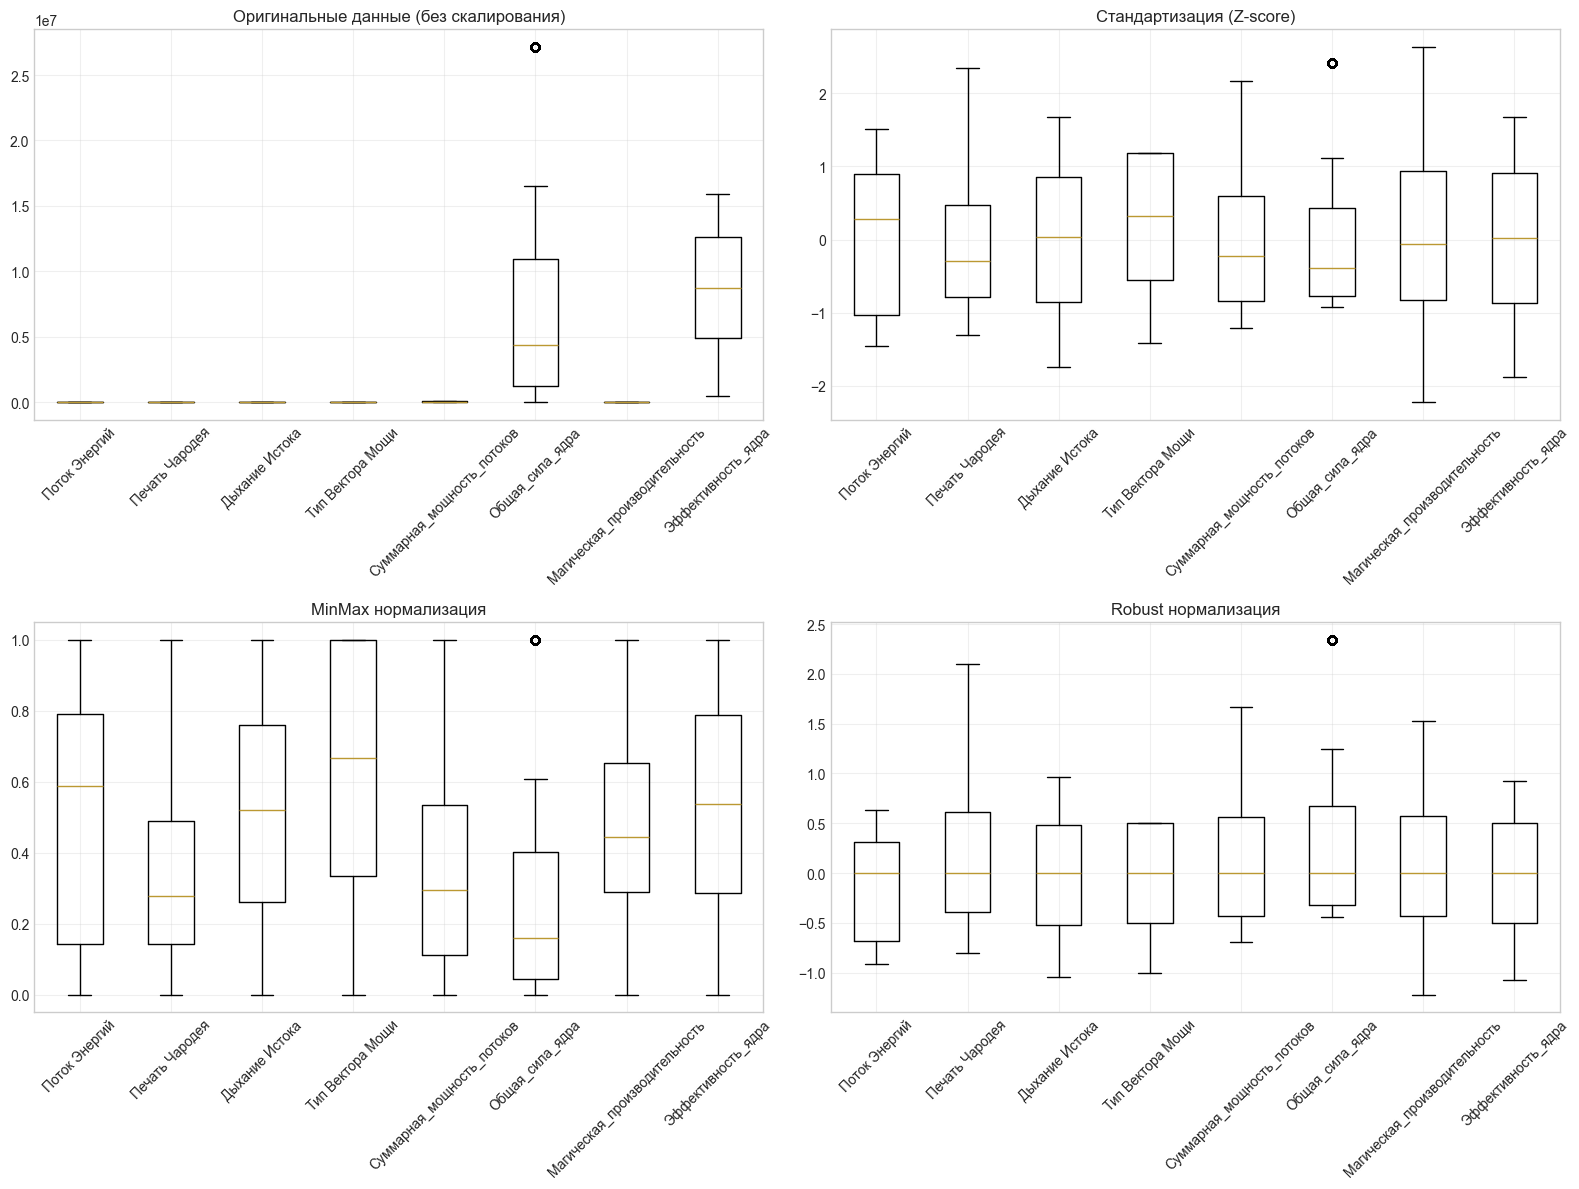


Стандартные отклонения после разных видов скалирования:

1. Стандартизация:
Поток Энергий                   1.000
Печать Чародея                  1.000
Дыхание Истока                  1.000
Тип Вектора Мощи                1.000
Суммарная_мощность_потоков      1.000
Общая_сила_ядра                 1.000
Магическая_производительность   1.000
Эффективность_ядра              1.000
dtype: float64

2. MinMax нормализация:
Поток Энергий                   0.337
Печать Чародея                  0.273
Дыхание Истока                  0.293
Тип Вектора Мощи                0.384
Суммарная_мощность_потоков      0.296
Общая_сила_ядра                 0.300
Магическая_производительность   0.206
Эффективность_ядра              0.282
dtype: float64

3. Robust нормализация:
Поток Энергий                   0.519
Печать Чародея                  0.794
Дыхание Истока                  0.586
Тип Вектора Мощи                0.577
Суммарная_мощность_потоков      0.700
Общая_сила_ядра                 0.836
Магичес

In [317]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].boxplot([X_train_original[col] for col in X_train_original.columns], labels=X_train_original.columns)
axes[0, 0].set_title('Оригинальные данные (без скалирования)')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].boxplot([X_train_standard[col] for col in X_train_standard.columns], labels=X_train_standard.columns)
axes[0, 1].set_title('Стандартизация (Z-score)')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].boxplot([X_train_minmax[col] for col in X_train_minmax.columns], labels=X_train_minmax.columns)
axes[1, 0].set_title('MinMax нормализация')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].boxplot([X_train_robust[col] for col in X_train_robust.columns], labels=X_train_robust.columns)
axes[1, 1].set_title('Robust нормализация')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nСтандартные отклонения после разных видов скалирования:")
print("\n1. Стандартизация:")
print(X_train_standard.std())
print("\n2. MinMax нормализация:")
print(X_train_minmax.std())
print("\n3. Robust нормализация:")
print(X_train_robust.std())